In [ ]:
# ============================================================
# Effect of Digital Currency on Finance and Accounting:
# Challenges Associated with Taxation and Legislation in the UK
# ============================================================

In [ ]:
# ============================================================
# SECTION 1: INSTALL AND IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [ ]:
# ============================================================
# SECTION 2: LOAD DATA
# ============================================================

btc = pd.read_csv('BITCOIN24.csv')
eth = pd.read_csv('ETHEREUM.csv')
ltc = pd.read_csv('LITECOIN24.csv')

print("Files loaded successfully.")
print(f"BTC rows: {len(btc)} | ETH rows: {len(eth)} | LTC rows: {len(ltc)}")

Files loaded successfully.
BTC rows: 2250 | ETH rows: 2404 | LTC rows: 2404


In [ ]:
# ============================================================
# SECTION 3: PRE-PROCESSING
# ============================================================

# Step 1: Convert Date column to datetime format
btc['Date'] = pd.to_datetime(btc['Date'], dayfirst=True)
eth['Date'] = pd.to_datetime(eth['Date'], dayfirst=True)
ltc['Date'] = pd.to_datetime(ltc['Date'], dayfirst=True)

# Step 2: Convert ETH and LTC numeric columns from string to float
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
for col in numeric_cols:
    eth[col] = pd.to_numeric(eth[col], errors='coerce')
    ltc[col] = pd.to_numeric(ltc[col], errors='coerce')

# Step 3: Sort all files chronologically ascending
btc = btc.sort_values('Date').reset_index(drop=True)
eth = eth.sort_values('Date').reset_index(drop=True)
ltc = ltc.sort_values('Date').reset_index(drop=True)

# Step 4: Check and remove null values
print("\nNull values before cleaning:")
print(f"BTC: {btc.isnull().sum().sum()}")
print(f"ETH: {eth[['Open','High','Low','Close','Volume']].isnull().sum().sum()}")
print(f"LTC: {ltc[['Open','High','Low','Close','Volume']].isnull().sum().sum()}")

eth = eth.dropna(subset=['Close']).reset_index(drop=True)
ltc = ltc.dropna(subset=['Close']).reset_index(drop=True)

print("\nNull values after cleaning:")
print(f"ETH: {eth['Close'].isnull().sum()}")
print(f"LTC: {ltc['Close'].isnull().sum()}")

# Step 5: Check for duplicate dates
print(f"\nDuplicate dates - BTC: {btc.duplicated(subset=['Date']).sum()}")
print(f"Duplicate dates - ETH: {eth.duplicated(subset=['Date']).sum()}")
print(f"Duplicate dates - LTC: {ltc.duplicated(subset=['Date']).sum()}")

# Step 6: Drop Adj Close (identical to Close)
eth = eth.drop(columns=['Adj Close'])
ltc = ltc.drop(columns=['Adj Close'])

print("\nPre-processing complete.")
print(f"Usable rows - BTC: {len(btc)} | ETH: {len(eth)} | LTC: {len(ltc)}")


Null values before cleaning:
BTC: 0
ETH: 65
LTC: 14

Null values after cleaning:
ETH: 0
LTC: 0

Duplicate dates - BTC: 0
Duplicate dates - ETH: 0
Duplicate dates - LTC: 0

Pre-processing complete.
Usable rows - BTC: 2250 | ETH: 2391 | LTC: 2404


In [ ]:
# ============================================================
# SECTION 4: DATASET STRUCTURE SUMMARY
# ============================================================

print("\n" + "="*60)
print("DATASET STRUCTURE SUMMARY")
print("="*60)

for name, df in [('Bitcoin', btc), ('Ethereum', eth), ('Litecoin', ltc)]:
    print(f"\n{name}:")
    print(f"  Date range : {df['Date'].min().date()} to {df['Date'].max().date()}")
    print(f"  Total rows : {len(df)}")
    print(f"  Columns    : {list(df.columns)}")


DATASET STRUCTURE SUMMARY

Bitcoin:
  Date range : 2018-01-01 to 2024-02-28
  Total rows : 2250
  Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Market Cap']

Ethereum:
  Date range : 2018-01-01 to 2024-07-18
  Total rows : 2391
  Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']

Litecoin:
  Date range : 2018-01-01 to 2024-07-31
  Total rows : 2404
  Columns    : ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']


In [ ]:
# ============================================================
# SECTION 5: DESCRIPTIVE STATISTICS (TABLE 1)
# ============================================================

print("\n" + "="*60)
print("TABLE 1: DESCRIPTIVE STATISTICS - DAILY CLOSING PRICE (USD)")
print("="*60)

desc_stats = pd.DataFrame({
    'Bitcoin (BTC)': btc['Close'].describe(),
    'Ethereum (ETH)': eth['Close'].describe(),
    'Litecoin (LTC)': ltc['Close'].describe()
}).round(2)

skew_row = pd.DataFrame({
    'Bitcoin (BTC)': [round(btc['Close'].skew(), 4)],
    'Ethereum (ETH)': [round(eth['Close'].skew(), 4)],
    'Litecoin (LTC)': [round(ltc['Close'].skew(), 4)]
}, index=['skewness'])

kurt_row = pd.DataFrame({
    'Bitcoin (BTC)': [round(btc['Close'].kurtosis(), 4)],
    'Ethereum (ETH)': [round(eth['Close'].kurtosis(), 4)],
    'Litecoin (LTC)': [round(ltc['Close'].kurtosis(), 4)]
}, index=['kurtosis'])

desc_stats = pd.concat([desc_stats, skew_row, kurt_row])
print(desc_stats.to_string())


TABLE 1: DESCRIPTIVE STATISTICS - DAILY CLOSING PRICE (USD)
          Bitcoin (BTC)  Ethereum (ETH)  Litecoin (LTC)
count         2250.0000       2391.0000       2404.0000
mean         22365.8500       1413.8700         94.8600
std          16269.7000       1207.1000         54.2500
min           3236.7000         84.3100         23.4600
25%           8446.8500        242.0300         57.7200
50%          18293.4700       1271.6500         76.8400
75%          34568.1700       2148.3700        117.4800
max          67500.0200       4812.0900        386.4500
skewness         0.7428          0.6776          1.5823
kurtosis        -0.5917         -0.6095          2.7738


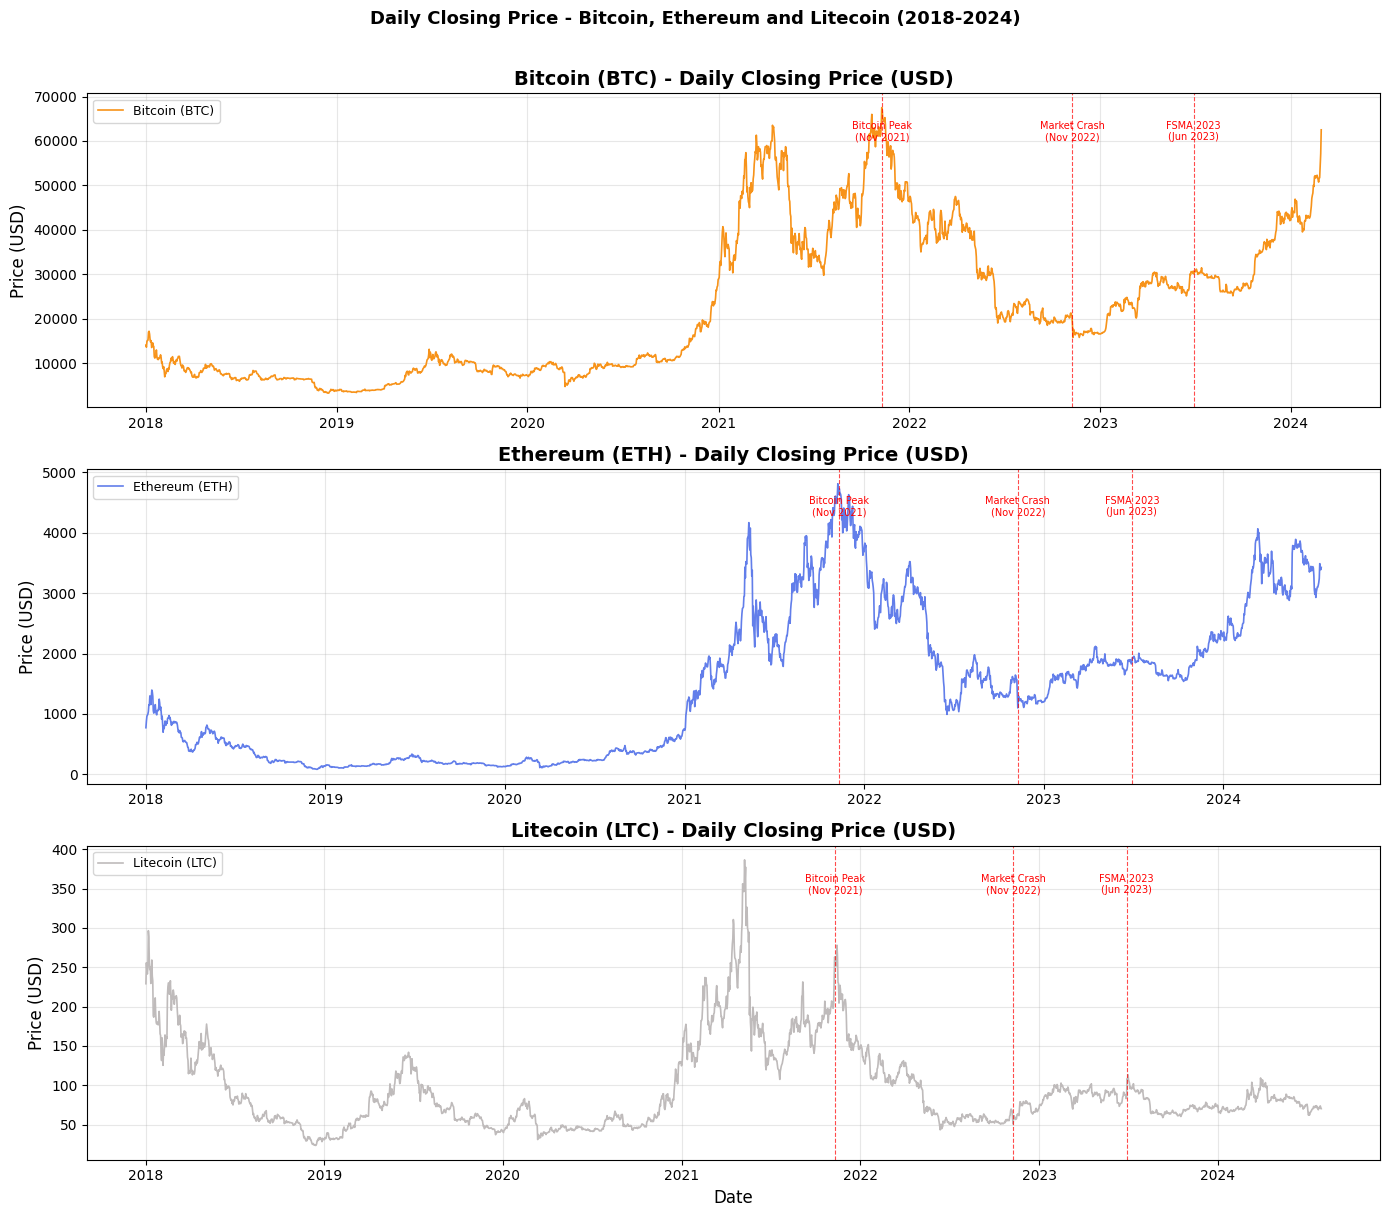

In [ ]:
# ============================================================
# SECTION 6: CLOSING PRICE TIME SERIES
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Key regulatory event dates
regulatory_dates = {
    'Bitcoin Peak\n(Nov 2021)': '2021-11-10',
    'Market Crash\n(Nov 2022)': '2022-11-09',
    'FSMA 2023\n(Jun 2023)': '2023-06-29'
}

colors = ['#F7931A', '#627EEA', '#BFBBBB']
assets = [('Bitcoin (BTC)', btc, colors[0]),
          ('Ethereum (ETH)', eth, colors[1]),
          ('Litecoin (LTC)', ltc, colors[2])]

for ax, (name, df, color) in zip(axes, assets):
    ax.plot(df['Date'], df['Close'], color=color, linewidth=1.2, label=name)
    for label, date in regulatory_dates.items():
        dt = pd.Timestamp(date)
        if dt >= df['Date'].min() and dt <= df['Date'].max():
            ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
            ax.text(dt, ax.get_ylim()[1] * 0.85, label,
                    fontsize=7, color='red', ha='center')
    ax.set_title(f'{name} - Daily Closing Price (USD)', fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

axes[2].set_xlabel('Date')
plt.suptitle('Daily Closing Price - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

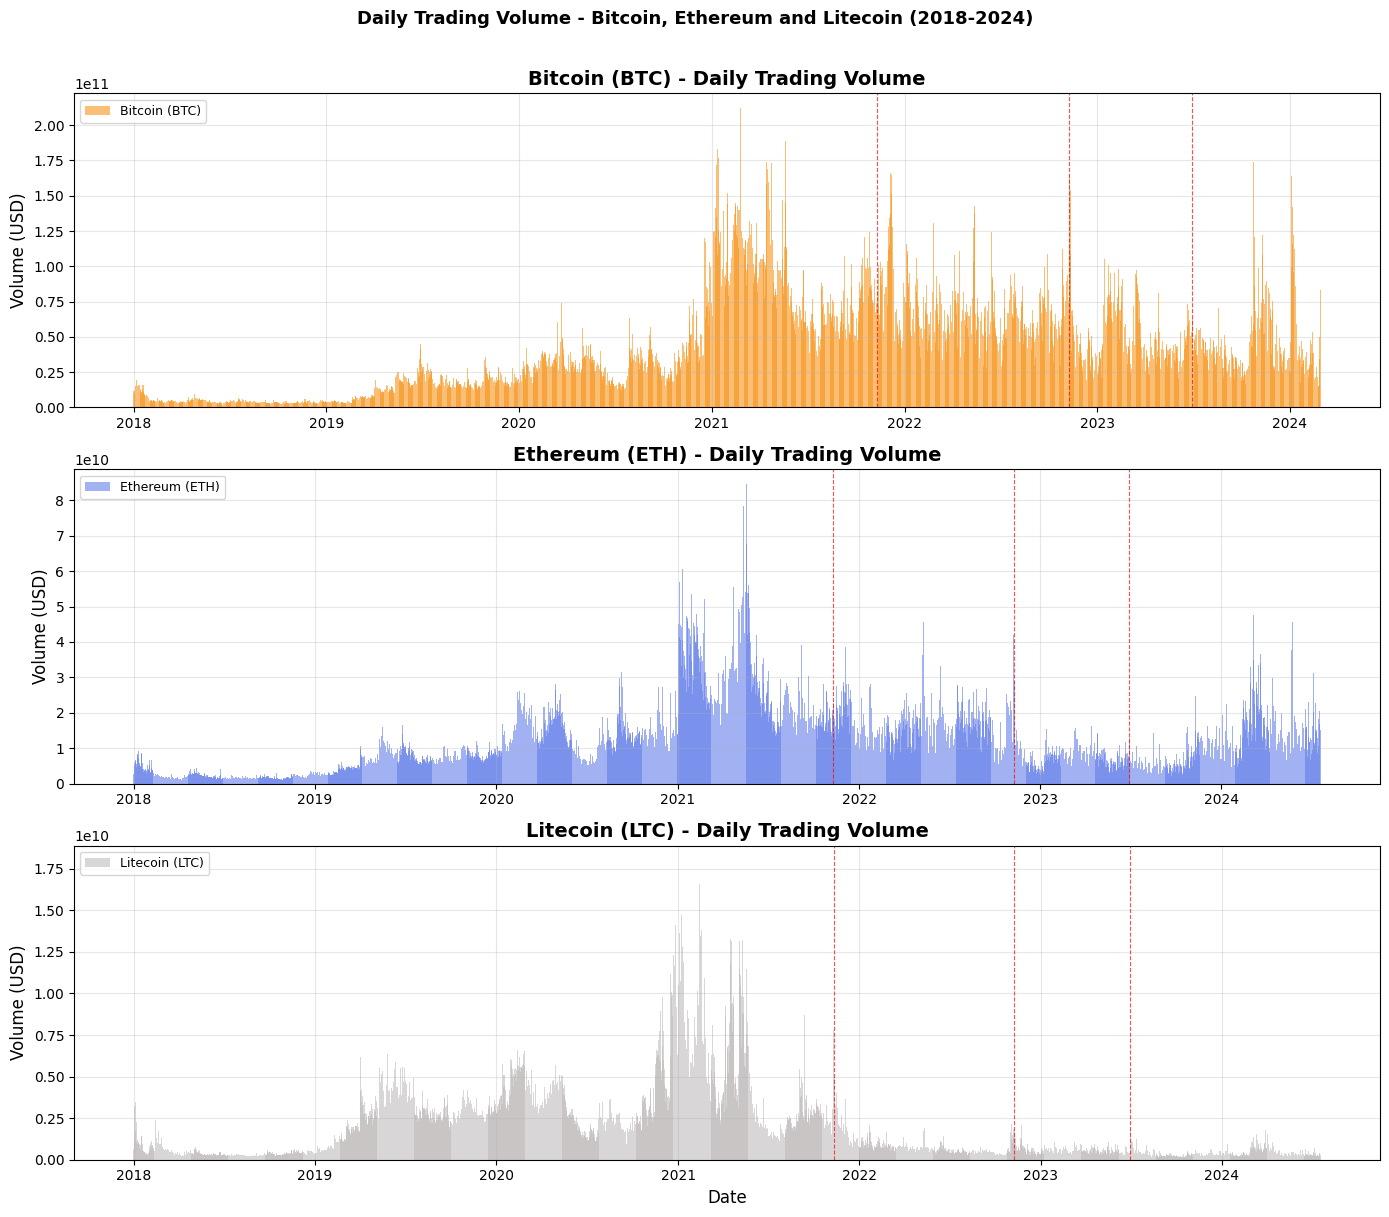

In [ ]:
# ============================================================
# SECTION 7: TRADING VOLUME TIME SERIES
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

for ax, (name, df, color) in zip(axes, assets):
    ax.bar(df['Date'], df['Volume'], color=color, alpha=0.6, width=1.5, label=name)
    for label, date in regulatory_dates.items():
        dt = pd.Timestamp(date)
        if dt >= df['Date'].min() and dt <= df['Date'].max():
            ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_title(f'{name} - Daily Trading Volume', fontweight='bold')
    ax.set_ylabel('Volume (USD)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

axes[2].set_xlabel('Date')
plt.suptitle('Daily Trading Volume - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

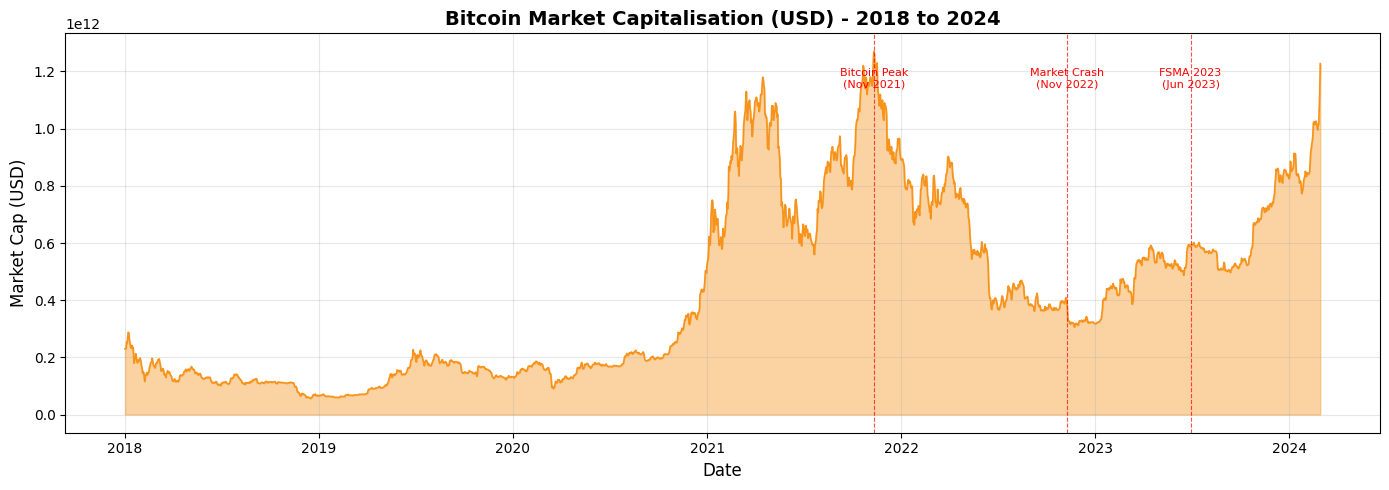

In [ ]:
# ============================================================
# SECTION 8: BITCOIN MARKET CAPITALISATION
# ============================================================

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(btc['Date'], btc['Market Cap'], color='#F7931A', alpha=0.4)
ax.plot(btc['Date'], btc['Market Cap'], color='#F7931A', linewidth=1.2)

for label, date in regulatory_dates.items():
    dt = pd.Timestamp(date)
    ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(dt, btc['Market Cap'].max() * 0.9, label,
            fontsize=8, color='red', ha='center')

ax.set_title('Bitcoin Market Capitalisation (USD) - 2018 to 2024',
             fontweight='bold')
ax.set_ylabel('Market Cap (USD)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 9: CORRELATION ANALYSIS (TABLE 2)
# ============================================================

# Merge on overlapping dates
merged = btc[['Date', 'Close']].merge(
    eth[['Date', 'Close']], on='Date', suffixes=('_btc', '_eth')
).merge(ltc[['Date', 'Close']], on='Date')
merged.rename(columns={'Close': 'Close_ltc'}, inplace=True)

corr_matrix = merged[['Close_btc', 'Close_eth', 'Close_ltc']].corr().round(4)
corr_matrix.index = ['Bitcoin', 'Ethereum', 'Litecoin']
corr_matrix.columns = ['Bitcoin', 'Ethereum', 'Litecoin']

print("\n" + "="*60)
print("TABLE 2: PEARSON CORRELATION MATRIX - DAILY CLOSING PRICES")
print(f"(Overlapping period: {merged['Date'].min().date()} to {merged['Date'].max().date()}, n={len(merged)} days)")
print("="*60)
print(corr_matrix.to_string())


TABLE 2: PEARSON CORRELATION MATRIX - DAILY CLOSING PRICES
(Overlapping period: 2018-01-01 to 2024-02-28, n=2250 days)
          Bitcoin  Ethereum  Litecoin
Bitcoin    1.0000    0.9263    0.6195
Ethereum   0.9263    1.0000    0.5855
Litecoin   0.6195    0.5855    1.0000


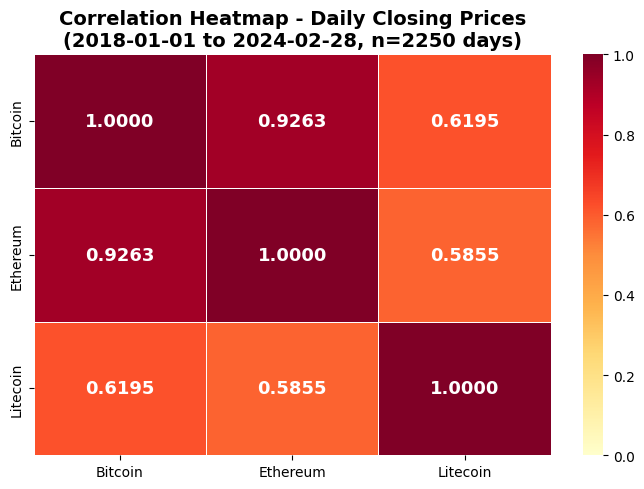

In [ ]:
# CORRELATION HEATMAP
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, vmin=0, vmax=1,
            annot_kws={'size': 13, 'weight': 'bold'})
ax.set_title('Correlation Heatmap - Daily Closing Prices\n'
             f'(2018-01-01 to 2024-02-28, n={len(merged)} days)',
             fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 10: VOLATILITY ANALYSIS - DAILY RETURNS (TABLE 3)
# ============================================================

# Calculate daily log returns
btc['Log_Return'] = np.log(btc['Close'] / btc['Close'].shift(1))
eth['Log_Return'] = np.log(eth['Close'] / eth['Close'].shift(1))
ltc['Log_Return'] = np.log(ltc['Close'] / ltc['Close'].shift(1))

# Annualised volatility (standard deviation of log returns * sqrt(365))
btc_vol = btc['Log_Return'].std() * np.sqrt(365)
eth_vol = eth['Log_Return'].std() * np.sqrt(365)
ltc_vol = ltc['Log_Return'].std() * np.sqrt(365)

print("\n" + "="*60)
print("TABLE 3: VOLATILITY ANALYSIS - DAILY LOG RETURNS")
print("="*60)

vol_stats = pd.DataFrame({
    'Bitcoin (BTC)': [
        round(btc['Log_Return'].mean() * 100, 4),
        round(btc['Log_Return'].std() * 100, 4),
        round(btc['Log_Return'].min() * 100, 4),
        round(btc['Log_Return'].max() * 100, 4),
        round(btc_vol * 100, 2)
    ],
    'Ethereum (ETH)': [
        round(eth['Log_Return'].mean() * 100, 4),
        round(eth['Log_Return'].std() * 100, 4),
        round(eth['Log_Return'].min() * 100, 4),
        round(eth['Log_Return'].max() * 100, 4),
        round(eth_vol * 100, 2)
    ],
    'Litecoin (LTC)': [
        round(ltc['Log_Return'].mean() * 100, 4),
        round(ltc['Log_Return'].std() * 100, 4),
        round(ltc['Log_Return'].min() * 100, 4),
        round(ltc['Log_Return'].max() * 100, 4),
        round(ltc_vol * 100, 2)
    ]
}, index=['Mean Daily Return (%)', 'Std Dev (%)', 'Min Return (%)',
          'Max Return (%)', 'Annualised Volatility (%)'])

print(vol_stats.to_string())


TABLE 3: VOLATILITY ANALYSIS - DAILY LOG RETURNS
                           Bitcoin (BTC)  Ethereum (ETH)  Litecoin (LTC)
Mean Daily Return (%)             0.0664          0.0623         -0.0492
Std Dev (%)                       3.7022          4.6413          4.9378
Min Return (%)                  -51.8084        -55.0732        -44.9062
Max Return (%)                   17.2829         23.0695         29.0594
Annualised Volatility (%)        70.7300         88.6700         94.3400


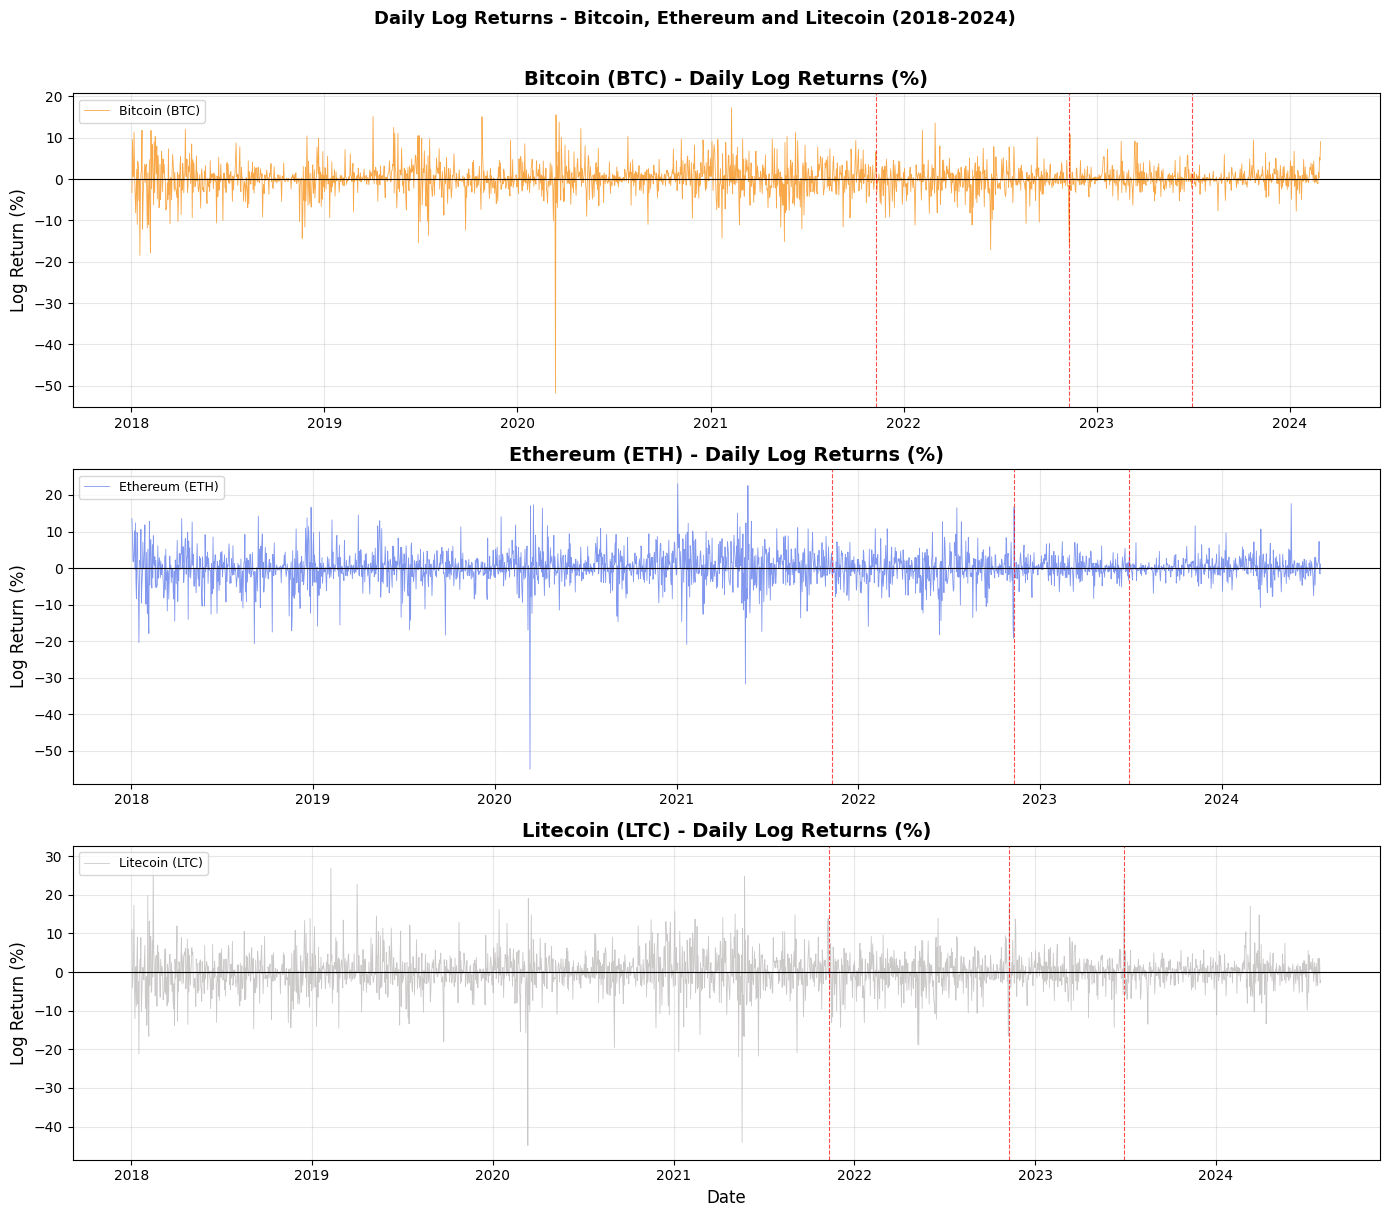

In [ ]:
# ============================================================
# SECTION 11: DAILY LOG RETURNS
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

return_colors = ['#F7931A', '#627EEA', '#BFBBBB']
return_assets = [('Bitcoin (BTC)', btc, return_colors[0]),
                 ('Ethereum (ETH)', eth, return_colors[1]),
                 ('Litecoin (LTC)', ltc, return_colors[2])]

for ax, (name, df, color) in zip(axes, return_assets):
    ax.plot(df['Date'], df['Log_Return'] * 100, color=color,
            linewidth=0.6, alpha=0.8, label=name)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    for label, date in regulatory_dates.items():
        dt = pd.Timestamp(date)
        if dt >= df['Date'].min() and dt <= df['Date'].max():
            ax.axvline(x=dt, color='red', linestyle='--',
                       linewidth=0.8, alpha=0.7)
    ax.set_title(f'{name} - Daily Log Returns (%)', fontweight='bold')
    ax.set_ylabel('Log Return (%)')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left', fontsize=9)

axes[2].set_xlabel('Date')
plt.suptitle('Daily Log Returns - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 12: CGT SIMULATION - OBJECTIVE 2
# Simulates annual CGT liability for a hypothetical UK investor
# holding a fixed quantity of each cryptocurrency
# Based on HMRC disposal rules: each year-end disposal is taxed
# at CGT rates with annual exempt amounts applied
# ============================================================

print("\n" + "="*60)
print("TABLE 4: SIMULATED ANNUAL CGT LIABILITY - UK INVESTOR")
print("Assumptions: 1 BTC | 10 ETH | 100 LTC purchased Jan 2018")
print("Annual disposal at year-end closing price")
print("CGT rate: 20% (higher rate taxpayer)")
print("="*60)

# Quantities held
BTC_QTY = 1
ETH_QTY = 10
LTC_QTY = 100

# Cost basis (Jan 2018 opening prices)
BTC_COST = float(btc[btc['Date'] == '2018-01-01']['Open'].values[0])
ETH_COST = float(eth[eth['Date'] == '2018-01-01']['Open'].values[0])
LTC_COST = float(ltc[ltc['Date'] == '2018-01-01']['Open'].values[0])

# Annual exempt amounts per HMRC
exempt_amounts = {
    2018: 11700, 2019: 12000, 2020: 12300, 2021: 12300,
    2022: 12300, 2023: 6000, 2024: 3000
}

# CGT rate for higher rate taxpayer
CGT_RATE = 0.20

cgt_results = []

for year in range(2018, 2025):
    # Get year-end closing prices
    year_end = f'{year}-12-31'
    btc_year = btc[btc['Date'].dt.year == year]
    eth_year = eth[eth['Date'].dt.year == year]
    ltc_year = ltc[ltc['Date'].dt.year == year]

    if len(btc_year) == 0:
        continue

    btc_price = float(btc_year['Close'].iloc[-1])
    eth_price = float(eth_year['Close'].iloc[-1]) if len(eth_year) > 0 else 0
    ltc_price = float(ltc_year['Close'].iloc[-1]) if len(ltc_year) > 0 else 0

    # Calculate gains
    btc_gain = (btc_price - BTC_COST) * BTC_QTY
    eth_gain = (eth_price - ETH_COST) * ETH_QTY
    ltc_gain = (ltc_price - LTC_COST) * LTC_QTY
    total_gain = btc_gain + eth_gain + ltc_gain

    # Apply annual exempt amount
    exempt = exempt_amounts.get(year, 3000)
    taxable_gain = max(0, total_gain - exempt)
    cgt_liability = taxable_gain * CGT_RATE

    cgt_results.append({
        'Tax Year': f'{year}/{str(year+1)[-2:]}',
        'BTC Close (USD)': round(btc_price, 2),
        'ETH Close (USD)': round(eth_price, 2),
        'LTC Close (USD)': round(ltc_price, 2),
        'Total Gain (USD)': round(total_gain, 2),
        'CGT Exempt (USD)': exempt,
        'Taxable Gain (USD)': round(taxable_gain, 2),
        'CGT Liability (USD)': round(cgt_liability, 2)
    })

cgt_df = pd.DataFrame(cgt_results)
print(cgt_df.to_string(index=False))



TABLE 4: SIMULATED ANNUAL CGT LIABILITY - UK INVESTOR
Assumptions: 1 BTC | 10 ETH | 100 LTC purchased Jan 2018
Annual disposal at year-end closing price
CGT rate: 20% (higher rate taxpayer)
Tax Year  BTC Close (USD)  ETH Close (USD)  LTC Close (USD)  Total Gain (USD)  CGT Exempt (USD)  Taxable Gain (USD)  CGT Liability (USD)
 2018/19          3863.17           133.37            30.47         -35076.52             11700                0.00                 0.00
 2019/20          7245.99           129.61            41.34         -30644.08             12000                0.00                 0.00
 2020/21         28810.02           737.80           124.69           5336.90             12300                0.00                 0.00
 2021/22         47161.01          3682.63           146.51          55318.62             12300            43018.62              8603.72
 2022/23         16603.75          1196.77            70.00          -7749.10             12300                0.00         

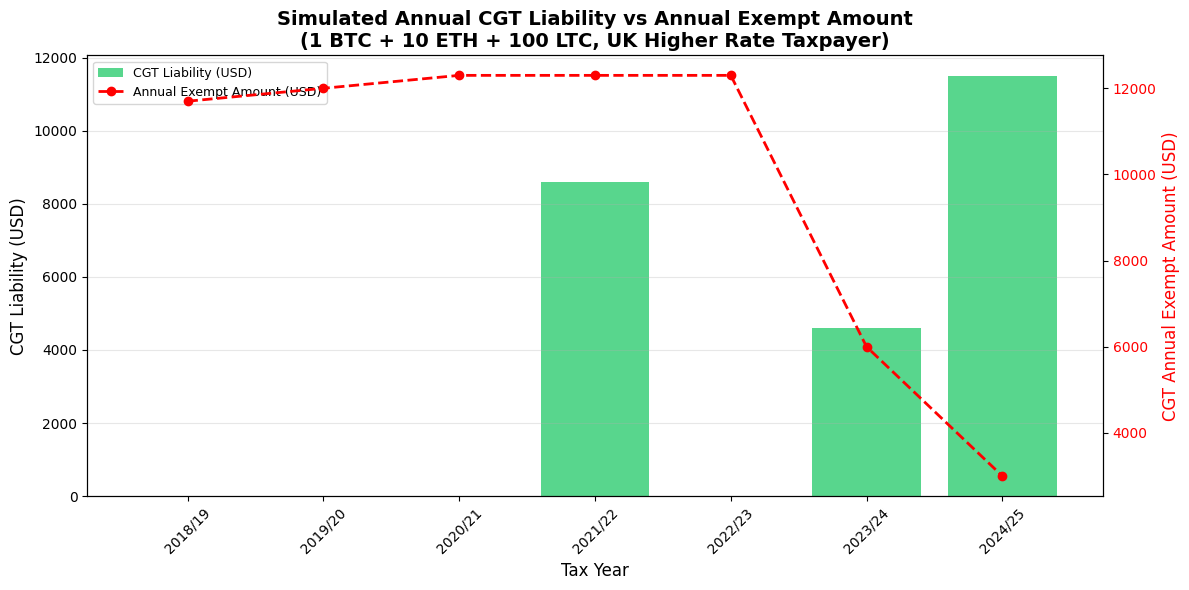

In [ ]:
# ============================================================
# SECTION 13: CGT LIABILITY OVER TIME
# ============================================================

fig, ax1 = plt.subplots(figsize=(12, 6))

x = range(len(cgt_df))
bars = ax1.bar(x, cgt_df['CGT Liability (USD)'],
               color=['#2ecc71' if v >= 0 else '#e74c3c'
                      for v in cgt_df['CGT Liability (USD)']],
               alpha=0.8, label='CGT Liability (USD)')

ax1.set_xlabel('Tax Year')
ax1.set_ylabel('CGT Liability (USD)', color='black')
ax1.set_xticks(x)
ax1.set_xticklabels(cgt_df['Tax Year'], rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

ax2 = ax1.twinx()
ax2.plot(x, cgt_df['CGT Exempt (USD)'], 'r--o',
         linewidth=2, markersize=6, label='Annual Exempt Amount (USD)')
ax2.set_ylabel('CGT Annual Exempt Amount (USD)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

plt.title('Simulated Annual CGT Liability vs Annual Exempt Amount\n'
          '(1 BTC + 10 ETH + 100 LTC, UK Higher Rate Taxpayer)',
          fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 14: REGULATORY EVENT IMPACT ANALYSIS - OBJECTIVE 3
# Examines price behaviour 30 days before and after key UK events
# ============================================================

print("\n" + "="*60)
print("TABLE 5: PRICE IMPACT OF KEY UK REGULATORY EVENTS")
print("(Average closing price 30 days before vs 30 days after)")
print("="*60)

events = {
    'FSMA 2023 Royal Assent (29 Jun 2023)': '2023-06-29',
    'HMRC CGT Reduction (06 Apr 2023)': '2023-04-06',
    'Bitcoin Market Peak (10 Nov 2021)': '2021-11-10',
    'Crypto Market Crash (09 Nov 2022)': '2022-11-09'
}

event_results = []

for event_name, event_date in events.items():
    dt = pd.Timestamp(event_date)
    for asset_name, df in [('Bitcoin', btc), ('Ethereum', eth), ('Litecoin', ltc)]:
        before = df[(df['Date'] >= dt - pd.Timedelta(days=30)) &
                    (df['Date'] < dt)]['Close'].mean()
        after = df[(df['Date'] > dt) &
                   (df['Date'] <= dt + pd.Timedelta(days=30))]['Close'].mean()
        if pd.notna(before) and pd.notna(after):
            change_pct = ((after - before) / before) * 100
            event_results.append({
                'Event': event_name,
                'Asset': asset_name,
                'Avg Price Before (USD)': round(before, 2),
                'Avg Price After (USD)': round(after, 2),
                'Price Change (%)': round(change_pct, 2)
            })

event_df = pd.DataFrame(event_results)
print(event_df.to_string(index=False))


TABLE 5: PRICE IMPACT OF KEY UK REGULATORY EVENTS
(Average closing price 30 days before vs 30 days after)
                               Event    Asset  Avg Price Before (USD)  Avg Price After (USD)  Price Change (%)
FSMA 2023 Royal Assent (29 Jun 2023)  Bitcoin                27476.71               30157.47              9.76
FSMA 2023 Royal Assent (29 Jun 2023) Ethereum                 1818.36                1896.97              4.32
FSMA 2023 Royal Assent (29 Jun 2023) Litecoin                   85.07                  96.60             13.55
    HMRC CGT Reduction (06 Apr 2023)  Bitcoin                25850.29               28949.99             11.99
    HMRC CGT Reduction (06 Apr 2023) Ethereum                 1718.58                1927.18             12.14
    HMRC CGT Reduction (06 Apr 2023) Litecoin                   85.73                  91.07              6.24
   Bitcoin Market Peak (10 Nov 2021)  Bitcoin                61114.67               57211.93             -6.39
   Bi

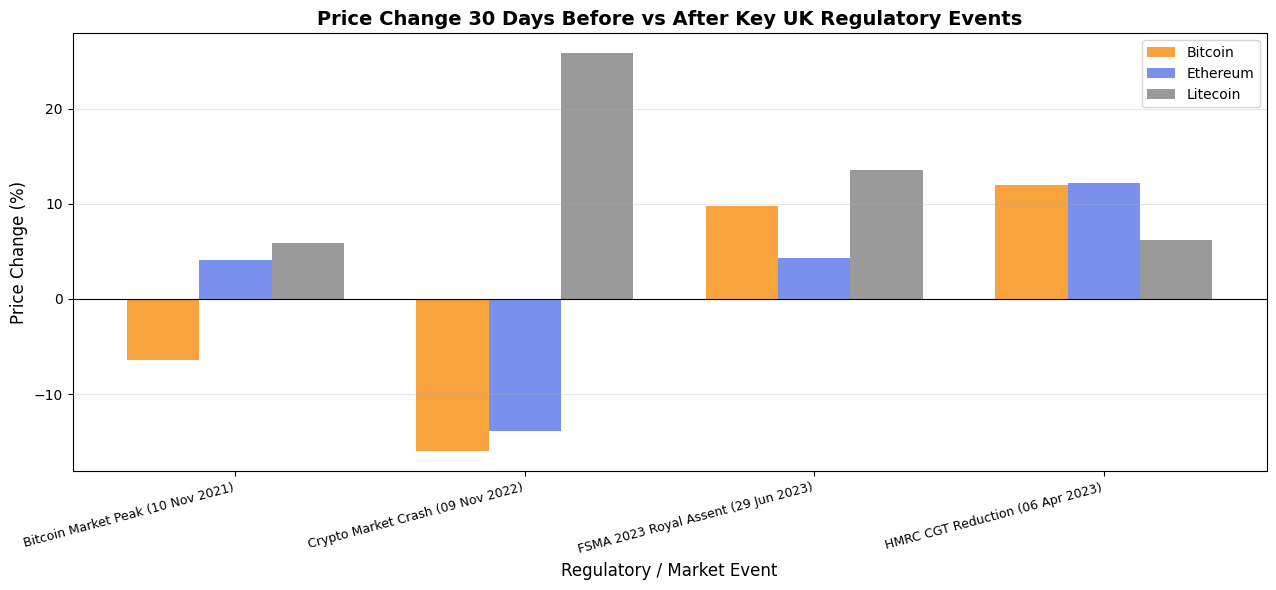

In [ ]:
# ============================================================
# SECTION 15: REGULATORY EVENT PRICE IMPACT
# ============================================================

fig, ax = plt.subplots(figsize=(13, 6))

pivot = event_df.pivot(index='Event', columns='Asset', values='Price Change (%)')
x = np.arange(len(pivot.index))
width = 0.25

bars1 = ax.bar(x - width, pivot['Bitcoin'], width,
               label='Bitcoin', color='#F7931A', alpha=0.85)
bars2 = ax.bar(x, pivot['Ethereum'], width,
               label='Ethereum', color='#627EEA', alpha=0.85)
bars3 = ax.bar(x + width, pivot['Litecoin'], width,
               label='Litecoin', color='#888888', alpha=0.85)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_xlabel('Regulatory / Market Event')
ax.set_ylabel('Price Change (%)')
ax.set_title('Price Change 30 Days Before vs After Key UK Regulatory Events',
             fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15, ha='right', fontsize=9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 16: RISK AND OPPORTUNITY ANALYSIS - OBJECTIVE 4
# Rolling 30-day volatility and Sharpe Ratio
# ============================================================

# Rolling 30-day volatility
btc['Rolling_Vol_30'] = btc['Log_Return'].rolling(window=30).std() * np.sqrt(365) * 100
eth['Rolling_Vol_30'] = eth['Log_Return'].rolling(window=30).std() * np.sqrt(365) * 100
ltc['Rolling_Vol_30'] = ltc['Log_Return'].rolling(window=30).std() * np.sqrt(365) * 100

# Sharpe Ratio (risk-free rate = 2% annual, approximate UK base rate average)
RISK_FREE_RATE = 0.02 / 365

btc_sharpe = (btc['Log_Return'].mean() - RISK_FREE_RATE) / btc['Log_Return'].std()
eth_sharpe = (eth['Log_Return'].mean() - RISK_FREE_RATE) / eth['Log_Return'].std()
ltc_sharpe = (ltc['Log_Return'].mean() - RISK_FREE_RATE) / ltc['Log_Return'].std()

print("\n" + "="*60)
print("TABLE 6: RISK AND RETURN SUMMARY - OBJECTIVE 4")
print("="*60)

risk_df = pd.DataFrame({
    'Metric': [
        'Annualised Volatility (%)',
        'Annualised Return (%)',
        'Sharpe Ratio (daily)',
        'Max Drawdown (%)',
        'Value at Risk 95% (daily %)'
    ],
    'Bitcoin': [
        round(btc_vol * 100, 2),
        round(btc['Log_Return'].mean() * 365 * 100, 2),
        round(btc_sharpe, 4),
        round(((btc['Close'] / btc['Close'].cummax()) - 1).min() * 100, 2),
        round(btc['Log_Return'].quantile(0.05) * 100, 4)
    ],
    'Ethereum': [
        round(eth_vol * 100, 2),
        round(eth['Log_Return'].mean() * 365 * 100, 2),
        round(eth_sharpe, 4),
        round(((eth['Close'] / eth['Close'].cummax()) - 1).min() * 100, 2),
        round(eth['Log_Return'].quantile(0.05) * 100, 4)
    ],
    'Litecoin': [
        round(ltc_vol * 100, 2),
        round(ltc['Log_Return'].mean() * 365 * 100, 2),
        round(ltc_sharpe, 4),
        round(((ltc['Close'] / ltc['Close'].cummax()) - 1).min() * 100, 2),
        round(ltc['Log_Return'].quantile(0.05) * 100, 4)
    ]
})
print(risk_df.to_string(index=False))


TABLE 6: RISK AND RETURN SUMMARY - OBJECTIVE 4
                     Metric  Bitcoin  Ethereum  Litecoin
  Annualised Volatility (%)  70.7300   88.6700   94.3400
      Annualised Return (%)  24.2400   22.7500  -17.9600
       Sharpe Ratio (daily)   0.0165    0.0122   -0.0111
           Max Drawdown (%) -81.1400  -93.9600  -92.0900
Value at Risk 95% (daily %)  -5.7300   -7.2160   -7.9345


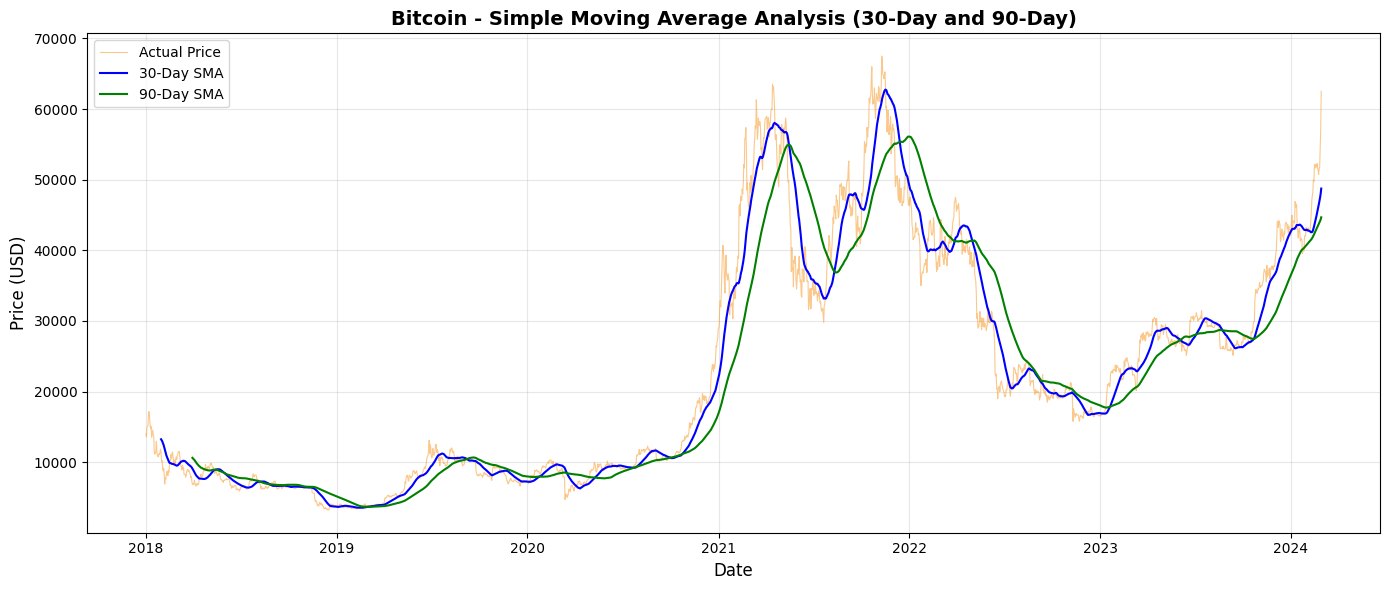


TABLE 7: SMA CROSSOVER SIGNALS - BITCOIN
(30-Day SMA crossing 90-Day SMA)
      Date       Close       SMA_30       SMA_90        Signal
2021-05-16 46786.61000 54754.819757 54920.921279 Bearish Cross
2021-08-11 45543.91666 37146.549820 36957.652466 Bullish Cross
2021-12-14 46745.62540 55038.041426 55338.363922 Bearish Cross
2022-03-29 46888.22115 41376.250398 41275.967337 Bullish Cross
2022-05-02 38467.09400 41160.278905 41360.143421 Bearish Cross
2023-01-20 21082.05820 17863.881671 17853.484146 Bullish Cross
2023-06-04 27060.80000 27291.959000 27349.043843 Bearish Cross
2023-07-04 31154.04000 28131.723000 28109.520601 Bullish Cross
2023-08-23 26048.09000 28668.702333 28677.698778 Bearish Cross
2023-10-22 29894.16000 27470.929000 27466.536222 Bullish Cross


In [ ]:
# ============================================================
# SECTION 17: MOVING AVERAGE FORECASTING - BITCOIN (OBJECTIVE 1)
# 30-day and 90-day Simple Moving Averages
# Informed by Phung Duy et al. (2024) time series methodology
# ============================================================

btc['SMA_30'] = btc['Close'].rolling(window=30).mean()
btc['SMA_90'] = btc['Close'].rolling(window=90).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(btc['Date'], btc['Close'],
        color='#F7931A', linewidth=0.8, alpha=0.5, label='Actual Price')
ax.plot(btc['Date'], btc['SMA_30'],
        color='blue', linewidth=1.5, label='30-Day SMA')
ax.plot(btc['Date'], btc['SMA_90'],
        color='green', linewidth=1.5, label='90-Day SMA')
ax.set_title('Bitcoin - Simple Moving Average Analysis (30-Day and 90-Day)',
             fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# SMA Crossover Signal Table
btc['Signal'] = 0
btc.loc[btc['SMA_30'] > btc['SMA_90'], 'Signal'] = 1
btc.loc[btc['SMA_30'] < btc['SMA_90'], 'Signal'] = -1

crossovers = btc[btc['Signal'].diff() != 0][['Date', 'Close', 'SMA_30', 'SMA_90', 'Signal']].dropna()
crossovers['Signal'] = crossovers['Signal'].map({1: 'Bullish Cross', -1: 'Bearish Cross'})

print("\nTABLE 7: SMA CROSSOVER SIGNALS - BITCOIN")
print("(30-Day SMA crossing 90-Day SMA)")
print(crossovers.tail(10).to_string(index=False))

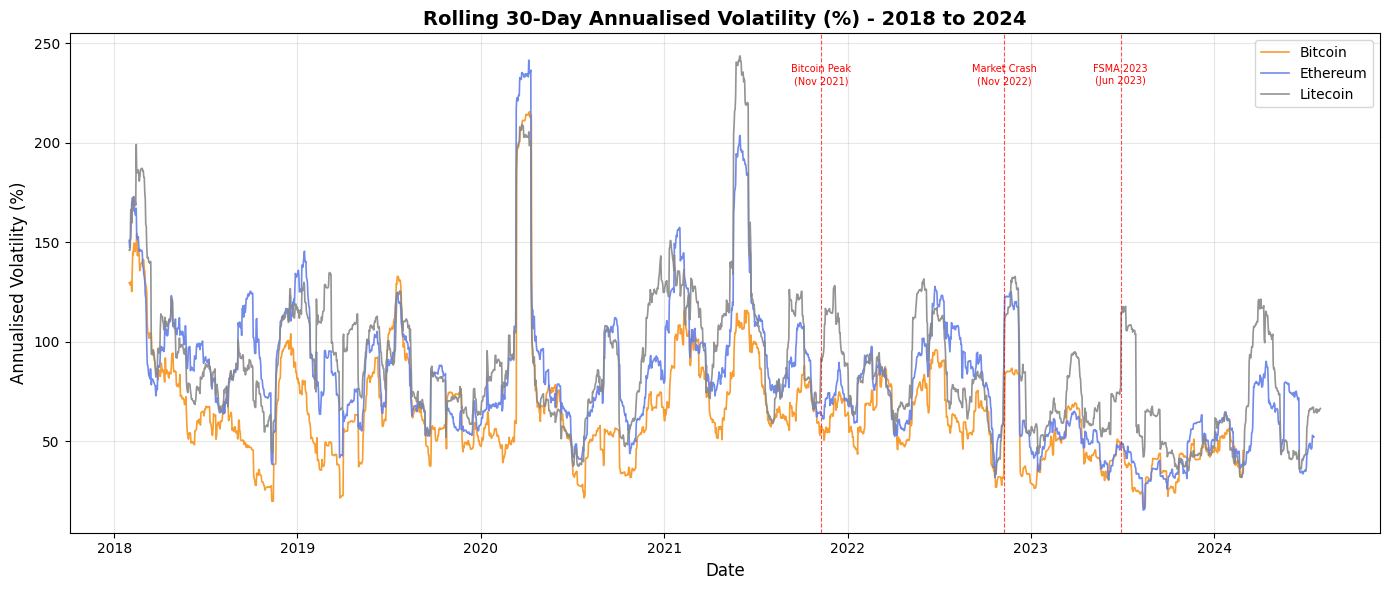

In [ ]:
# ============================================================
# SECTION 18: ROLLING 30-DAY VOLATILITY
# ============================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(btc['Date'], btc['Rolling_Vol_30'],
        color='#F7931A', linewidth=1.2, label='Bitcoin', alpha=0.9)
ax.plot(eth['Date'], eth['Rolling_Vol_30'],
        color='#627EEA', linewidth=1.2, label='Ethereum', alpha=0.9)
ax.plot(ltc['Date'], ltc['Rolling_Vol_30'],
        color='#888888', linewidth=1.2, label='Litecoin', alpha=0.9)

for label, date in regulatory_dates.items():
    dt = pd.Timestamp(date)
    ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.text(dt, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 200,
            label, fontsize=7, color='red', ha='center')

ax.set_title('Rolling 30-Day Annualised Volatility (%) - 2018 to 2024',
             fontweight='bold')
ax.set_ylabel('Annualised Volatility (%)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


TABLE: MONTHLY RETURN MATRIX - BITCOIN (%)
Month    Jan    Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec
Year                                                                                     
2018     NaN   6.47 -35.92  36.81 -21.27 -17.32  33.51 -14.76  -5.36  -4.78 -31.65 -10.06
2019  -10.16  10.68   8.41  26.27  59.37  44.35 -20.80   0.01 -15.80  13.56 -15.52  -6.39
2020   31.15  -8.12 -26.43  36.36  10.66  -5.30  21.01   5.30  -7.33  25.17  33.85  58.63
2021   19.17  34.57  27.04  -8.66 -33.56   0.62  17.45  11.70 -11.65  48.43  -6.14 -18.51
2022  -19.56  -0.59  24.89 -18.06 -17.81 -36.63  17.62 -16.39  -0.88   5.25 -20.30   1.02
2023   37.41   3.04  19.24   4.23  -5.25  10.03  -3.89  -6.69  -1.48  28.15   9.63  11.61
2024    1.70  45.65    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN


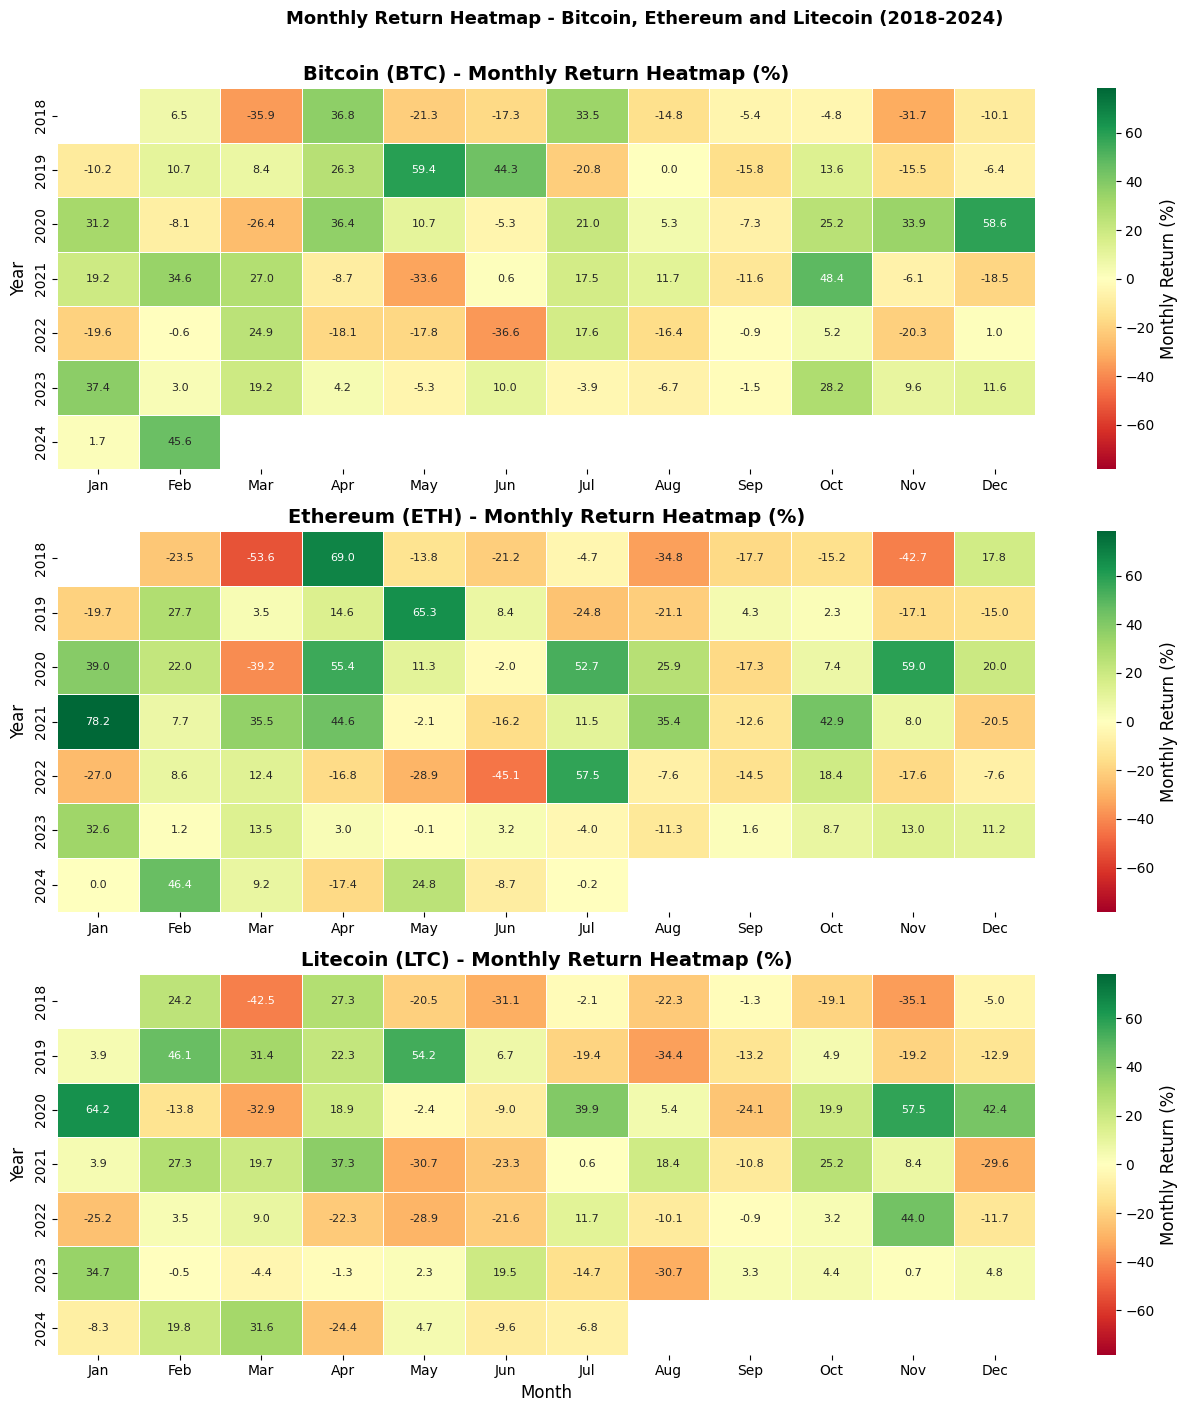

In [ ]:
# ============================================================
# SECTION 19: MONTHLY RETURN HEATMAP
# ============================================================

def monthly_return_matrix(price_df):
    close_series = price_df.set_index('Date')['Close']
    month_end_prices = close_series.resample('ME').last()
    monthly_returns = month_end_prices.pct_change() * 100

    returns_frame = monthly_returns.to_frame('Return')
    returns_frame['Year'] = returns_frame.index.year
    returns_frame['Month'] = returns_frame.index.strftime('%b')

    pivot = returns_frame.pivot(index='Year', columns='Month', values='Return')
    month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])
    return pivot


btc_monthly = monthly_return_matrix(btc)
eth_monthly = monthly_return_matrix(eth)
ltc_monthly = monthly_return_matrix(ltc)

print("\n" + "=" * 60)
print("TABLE: MONTHLY RETURN MATRIX - BITCOIN (%)")
print("=" * 60)
print(btc_monthly.round(2).to_string())

fig, axes = plt.subplots(3, 1, figsize=(13, 14))

asset_pivots = [('Bitcoin (BTC)', btc_monthly),
                 ('Ethereum (ETH)', eth_monthly),
                 ('Litecoin (LTC)', ltc_monthly)]

max_abs_return = max(pivot.abs().max().max() for _, pivot in asset_pivots)

for ax, (name, pivot) in zip(axes, asset_pivots):
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                vmin=-max_abs_return, vmax=max_abs_return, linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Monthly Return (%)'},
                annot_kws={'size': 8})
    ax.set_title(f'{name} - Monthly Return Heatmap (%)', fontweight='bold')
    ax.set_ylabel('Year')
    ax.set_xlabel('')

axes[2].set_xlabel('Month')
plt.suptitle('Monthly Return Heatmap - Bitcoin, Ethereum and Litecoin (2018-2024)',
             fontsize=13, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

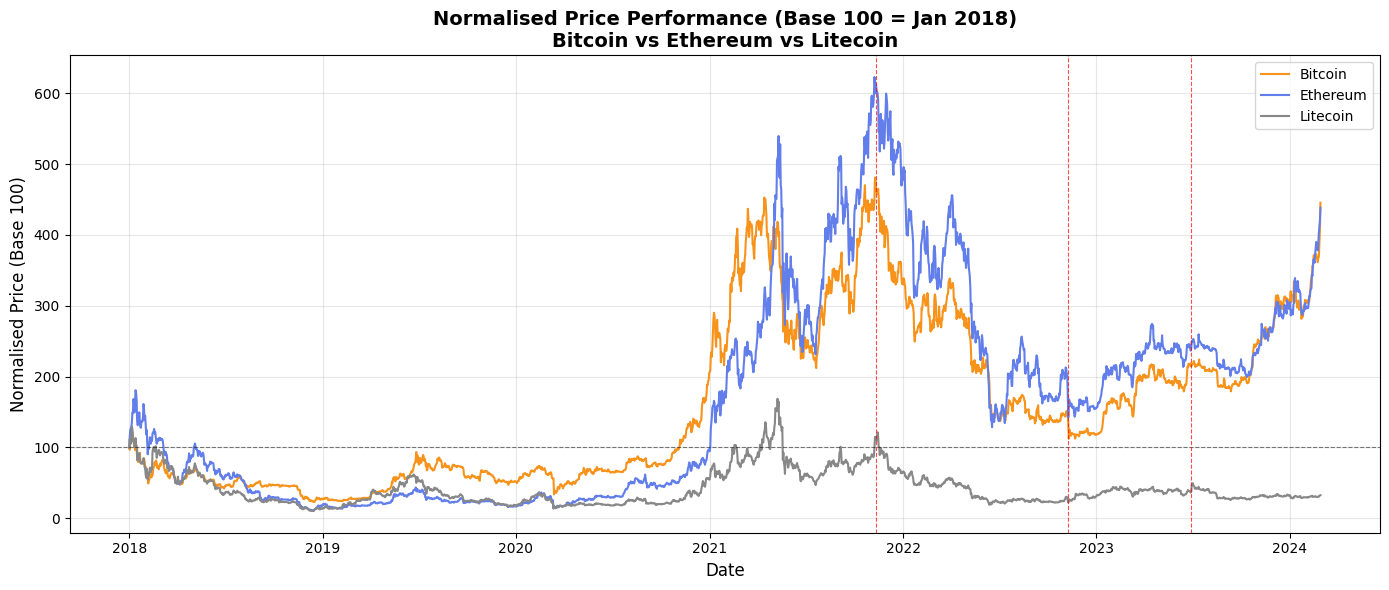

In [ ]:
# ============================================================
# SECTION 20: NORMALISED PRICE COMPARISON
# (Base 100 from Jan 2018 for direct comparison)
# ============================================================

# Merge on common dates
common = btc[['Date', 'Close']].merge(
    eth[['Date', 'Close']], on='Date', suffixes=('_btc', '_eth')
).merge(ltc[['Date', 'Close']], on='Date')
common.rename(columns={'Close': 'Close_ltc'}, inplace=True)

# Normalise to base 100
common['BTC_norm'] = (common['Close_btc'] / common['Close_btc'].iloc[0]) * 100
common['ETH_norm'] = (common['Close_eth'] / common['Close_eth'].iloc[0]) * 100
common['LTC_norm'] = (common['Close_ltc'] / common['Close_ltc'].iloc[0]) * 100

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(common['Date'], common['BTC_norm'],
        color='#F7931A', linewidth=1.5, label='Bitcoin')
ax.plot(common['Date'], common['ETH_norm'],
        color='#627EEA', linewidth=1.5, label='Ethereum')
ax.plot(common['Date'], common['LTC_norm'],
        color='#888888', linewidth=1.5, label='Litecoin')

ax.axhline(y=100, color='black', linewidth=0.8, linestyle='--', alpha=0.5)

for label, date in regulatory_dates.items():
    dt = pd.Timestamp(date)
    ax.axvline(x=dt, color='red', linestyle='--', linewidth=0.8, alpha=0.7)

ax.set_title('Normalised Price Performance (Base 100 = Jan 2018)\n'
             'Bitcoin vs Ethereum vs Litecoin', fontweight='bold')
ax.set_ylabel('Normalised Price (Base 100)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
 # ============================================================
 # SECTION 21: MACHINE LEARNING - FEATURE ENGINEERING
 # ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix)

RANDOM_STATE = 42


def compute_rsi(price_series, period=14):
    delta = price_series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def engineer_features(price_df, forward_window=10):
    data = price_df.copy()

    data['Log_Return'] = np.log(data['Close'] / data['Close'].shift(1))
    data['Return_1'] = data['Close'].pct_change(1)
    data['Return_3'] = data['Close'].pct_change(3)
    data['Return_7'] = data['Close'].pct_change(7)

    data['Volatility_3'] = data['Log_Return'].rolling(3).std()
    data['Volatility_7'] = data['Log_Return'].rolling(7).std()
    data['Volatility_14'] = data['Log_Return'].rolling(14).std()

    data['SMA_10'] = data['Close'].rolling(10).mean()
    data['SMA_30'] = data['Close'].rolling(30).mean()
    data['SMA_Ratio'] = data['SMA_10'] / data['SMA_30']
    data['Price_SMA10_Ratio'] = data['Close'] / data['SMA_10']

    data['RSI_14'] = compute_rsi(data['Close'], 14)

    data['Volume_Change'] = data['Volume'].pct_change(1)
    data['Volume_MA_Ratio'] = data['Volume'] / data['Volume'].rolling(14).mean()

    data['HL_Range'] = (data['High'] - data['Low']) / data['Close']
    data['OC_Change'] = (data['Close'] - data['Open']) / data['Open']
    data['Momentum_10'] = (data['Close'] - data['Close'].shift(10)) / data['Close'].shift(10)

    data['AbsReturn_1'] = data['Return_1'].abs()
    data['AbsReturn_3'] = data['Return_1'].rolling(3).apply(lambda x: np.abs(x).mean())

    rolling_std_20 = data['Close'].rolling(20).std()
    rolling_mean_20 = data['Close'].rolling(20).mean()
    data['BB_Width'] = (4 * rolling_std_20) / rolling_mean_20
    data['ATR_14'] = (data['High'] - data['Low']).rolling(14).mean() / data['Close']

    forward_volatility = (data['Log_Return'].shift(-1)
                           .rolling(forward_window).std()
                           .shift(-(forward_window - 1)))
    data['Target'] = (forward_volatility > data['Volatility_7']).astype(int)

    data = data.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)
    return data


FEATURE_COLUMNS = [
    'Return_1', 'Return_3', 'Return_7',
    'Volatility_3', 'Volatility_7', 'Volatility_14',
    'SMA_Ratio', 'Price_SMA10_Ratio', 'RSI_14',
    'Volume_Change', 'Volume_MA_Ratio',
    'HL_Range', 'OC_Change', 'Momentum_10',
    'AbsReturn_1', 'AbsReturn_3', 'BB_Width', 'ATR_14'
]

btc_ml = engineer_features(btc)
eth_ml = engineer_features(eth)
ltc_ml = engineer_features(ltc)

print("\n" + "=" * 60)
print("TABLE 8: FEATURE-ENGINEERED DATASET SIZE AND CLASS BALANCE")
print("=" * 60)
for asset_name, asset_df in [('Bitcoin', btc_ml), ('Ethereum', eth_ml), ('Litecoin', ltc_ml)]:
    print(f"{asset_name:10s} rows={len(asset_df):5d}  "
          f"positive class share={asset_df['Target'].mean():.3f}")


TABLE 8: FEATURE-ENGINEERED DATASET SIZE AND CLASS BALANCE
Bitcoin    rows= 2161  positive class share=0.503
Ethereum   rows= 2361  positive class share=0.518
Litecoin   rows= 2360  positive class share=0.529


In [ ]:
# ============================================================
# SECTION 22: TRAIN-TEST SPLIT (CHRONOLOGICAL, 80/20)
# ============================================================

def chronological_split(feature_df, test_size=0.2):
    split_point = int(len(feature_df) * (1 - test_size))
    X = feature_df[FEATURE_COLUMNS]
    y = feature_df['Target']
    X_train, X_test = X.iloc[:split_point], X.iloc[split_point:]
    y_train, y_test = y.iloc[:split_point], y.iloc[split_point:]
    return X_train, X_test, y_train, y_test


splits = {
    'Bitcoin': chronological_split(btc_ml),
    'Ethereum': chronological_split(eth_ml),
    'Litecoin': chronological_split(ltc_ml)
}

In [ ]:
# ============================================================
# SECTION 23: HYPERPARAMETER TUNING AND MODEL TRAINING
# GridSearchCV with TimeSeriesSplit cross-validation is used
# for all three models, so hyperparameter selection never
# uses information from later time points to evaluate earlier
# ones.
# ============================================================

tscv = TimeSeriesSplit(n_splits=5)

logistic_param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 5],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}

random_forest_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [3, 5, 10]
}

xgboost_param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.01, 0.03, 0.05]
}

model_results = []
fitted_models = {}
confusion_matrices = {}

for asset_name, (X_train, X_test, y_train, y_test) in splits.items():

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    logistic_search = GridSearchCV(
        LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        logistic_param_grid, cv=tscv, scoring='accuracy', n_jobs=-1
    )
    logistic_search.fit(X_train_scaled, y_train)
    logistic_model = logistic_search.best_estimator_
    logistic_pred = logistic_model.predict(X_test_scaled)

    forest_search = GridSearchCV(
        RandomForestClassifier(random_state=RANDOM_STATE),
        random_forest_param_grid, cv=tscv, scoring='accuracy', n_jobs=-1
    )
    forest_search.fit(X_train, y_train)
    forest_model = forest_search.best_estimator_
    forest_pred = forest_model.predict(X_test)

    xgboost_search = GridSearchCV(
        XGBClassifier(eval_metric='logloss', random_state=RANDOM_STATE),
        xgboost_param_grid, cv=tscv, scoring='accuracy', n_jobs=-1
    )
    xgboost_search.fit(X_train, y_train)
    xgboost_model = xgboost_search.best_estimator_
    xgboost_pred = xgboost_model.predict(X_test)

    fitted_models[asset_name] = {
        'Logistic Regression': (logistic_model, logistic_pred, logistic_search.best_params_, scaler),
        'Random Forest': (forest_model, forest_pred, forest_search.best_params_, None),
        'XGBoost': (xgboost_model, xgboost_pred, xgboost_search.best_params_, None)
    }

    for model_name, (fitted_model, predictions, best_params, _) in fitted_models[asset_name].items():
        model_results.append({
            'Asset': asset_name,
            'Model': model_name,
            'Accuracy': round(accuracy_score(y_test, predictions), 4),
            'Precision': round(precision_score(y_test, predictions), 4),
            'Recall': round(recall_score(y_test, predictions), 4),
            'F1 Score': round(f1_score(y_test, predictions), 4),
            'Best Parameters': best_params
        })
        confusion_matrices[(asset_name, model_name)] = confusion_matrix(y_test, predictions)

results_df = pd.DataFrame(model_results)

print("\n" + "=" * 60)
print("TABLE 9: MODEL COMPARISON - ACCURACY, PRECISION, RECALL, F1")
print("=" * 60)
print(results_df[['Asset', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score']].to_string(index=False))

print("\n" + "=" * 60)
print("TABLE 10: BEST HYPERPARAMETERS PER MODEL")
print("=" * 60)
for row in model_results:
    print(f"{row['Asset']:10s} | {row['Model']:20s} | {row['Best Parameters']}")


TABLE 9: MODEL COMPARISON - ACCURACY, PRECISION, RECALL, F1
   Asset               Model  Accuracy  Precision  Recall  F1 Score
 Bitcoin Logistic Regression    0.7067     0.6555  0.9389    0.7720
 Bitcoin       Random Forest    0.6443     0.6126  0.8908    0.7260
 Bitcoin             XGBoost    0.6836     0.6420  0.9083    0.7523
Ethereum Logistic Regression    0.6406     0.6024  0.9883    0.7485
Ethereum       Random Forest    0.6195     0.5905  0.9688    0.7337
Ethereum             XGBoost    0.6110     0.5818  1.0000    0.7356
Litecoin Logistic Regression    0.7013     0.6721  0.9213    0.7773
Litecoin       Random Forest    0.6695     0.6427  0.9363    0.7622
Litecoin             XGBoost    0.6758     0.6477  0.9363    0.7657

TABLE 10: BEST HYPERPARAMETERS PER MODEL
Bitcoin    | Logistic Regression  | {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
Bitcoin    | Random Forest        | {'max_depth': 6, 'min_samples_leaf': 10, 'n_estimators': 200}
Bitcoin    | XGBoost              | {'

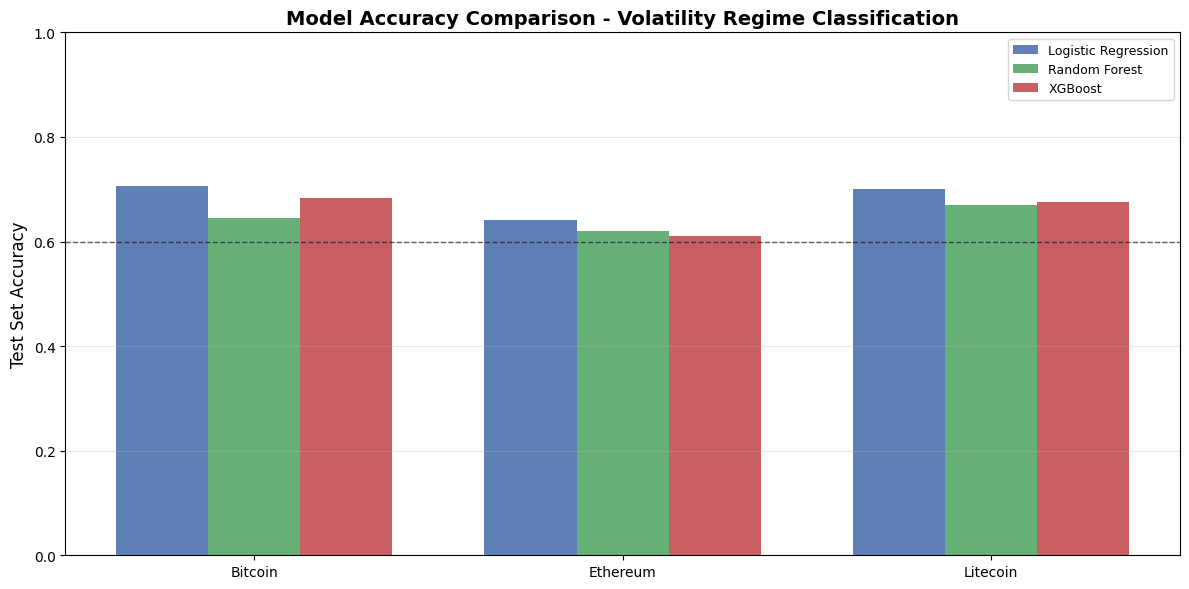

In [ ]:
# ============================================================
# SECTION 24: MODEL ACCURACY COMPARISON
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

assets_order = ['Bitcoin', 'Ethereum', 'Litecoin']
models_order = ['Logistic Regression', 'Random Forest', 'XGBoost']
model_colors = {'Logistic Regression': '#4C72B0', 'Random Forest': '#55A868', 'XGBoost': '#C44E52'}

bar_width = 0.25
x_positions = np.arange(len(assets_order))

for i, model_name in enumerate(models_order):
    accuracies = [
        results_df[(results_df['Asset'] == a) & (results_df['Model'] == model_name)]['Accuracy'].values[0]
        for a in assets_order
    ]
    ax.bar(x_positions + (i - 1) * bar_width, accuracies, width=bar_width,
           label=model_name, color=model_colors[model_name], alpha=0.9)

ax.axhline(y=0.6, color='black', linestyle='--', linewidth=1, alpha=0.6)
ax.set_xticks(x_positions)
ax.set_xticklabels(assets_order)
ax.set_ylabel('Test Set Accuracy')
ax.set_ylim(0, 1)
ax.set_title('Model Accuracy Comparison - Volatility Regime Classification', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

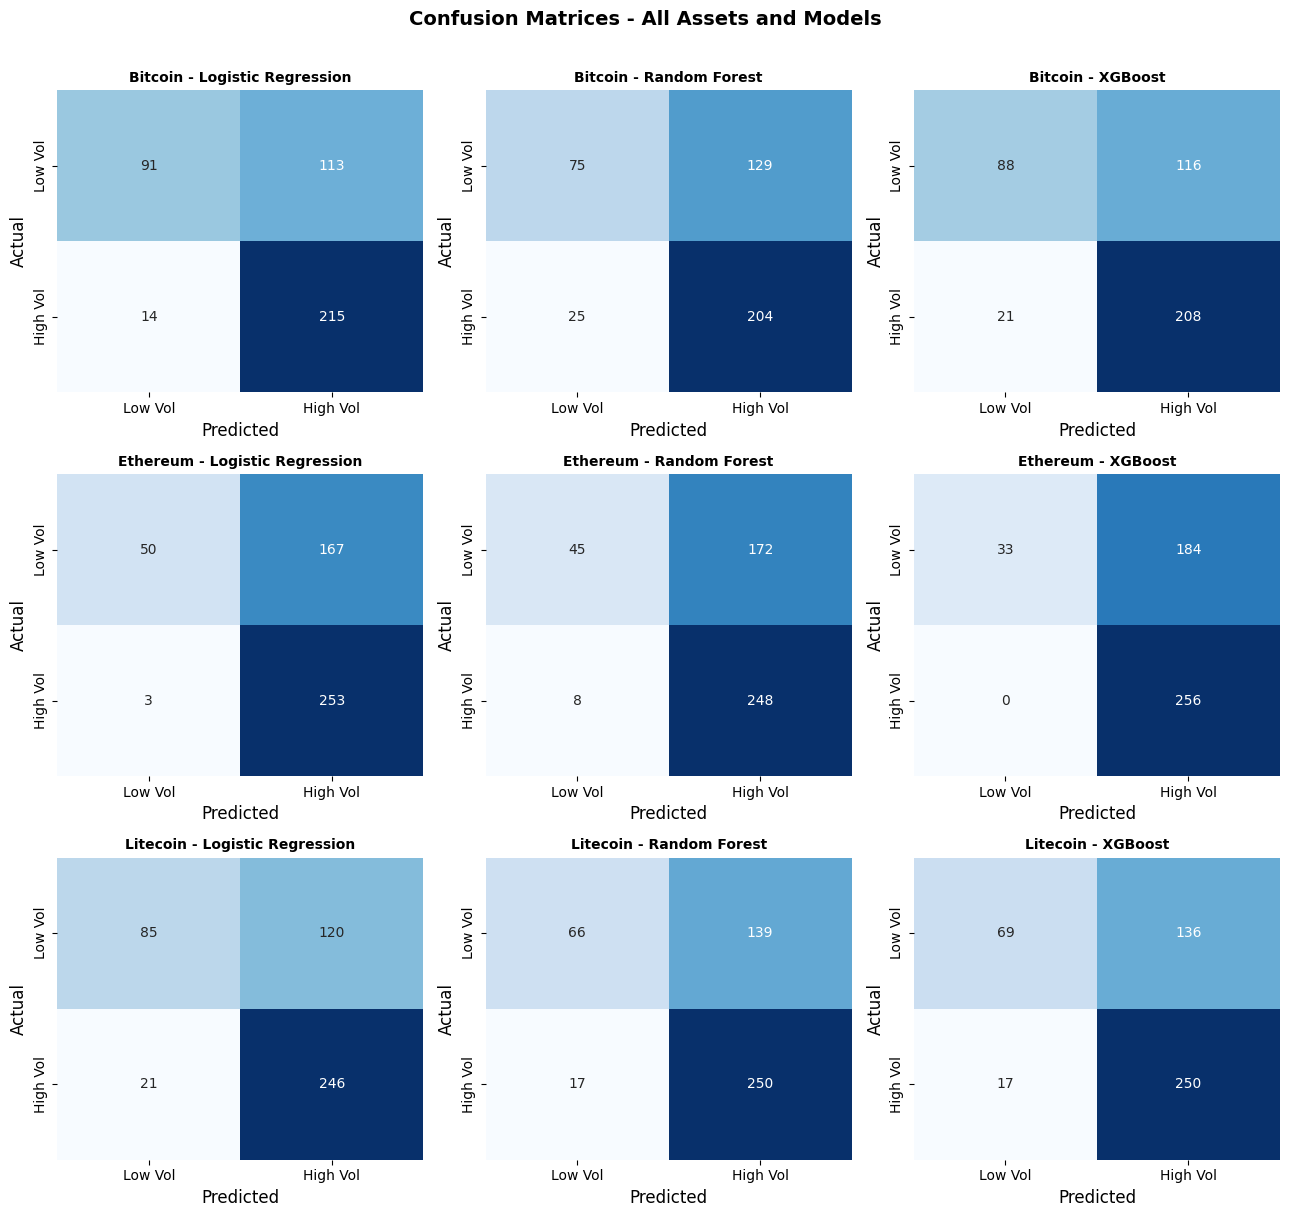

In [ ]:
# ============================================================
# SECTION 25: CONFUSION MATRICES
# ============================================================

fig, axes = plt.subplots(3, 3, figsize=(13, 12))

for row_idx, asset_name in enumerate(assets_order):
    for col_idx, model_name in enumerate(models_order):
        ax = axes[row_idx, col_idx]
        cm = confusion_matrices[(asset_name, model_name)]
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                    xticklabels=['Low Vol', 'High Vol'],
                    yticklabels=['Low Vol', 'High Vol'])
        ax.set_title(f'{asset_name} - {model_name}', fontsize=10, fontweight='bold')
        ax.set_ylabel('Actual')
        ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices - All Assets and Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

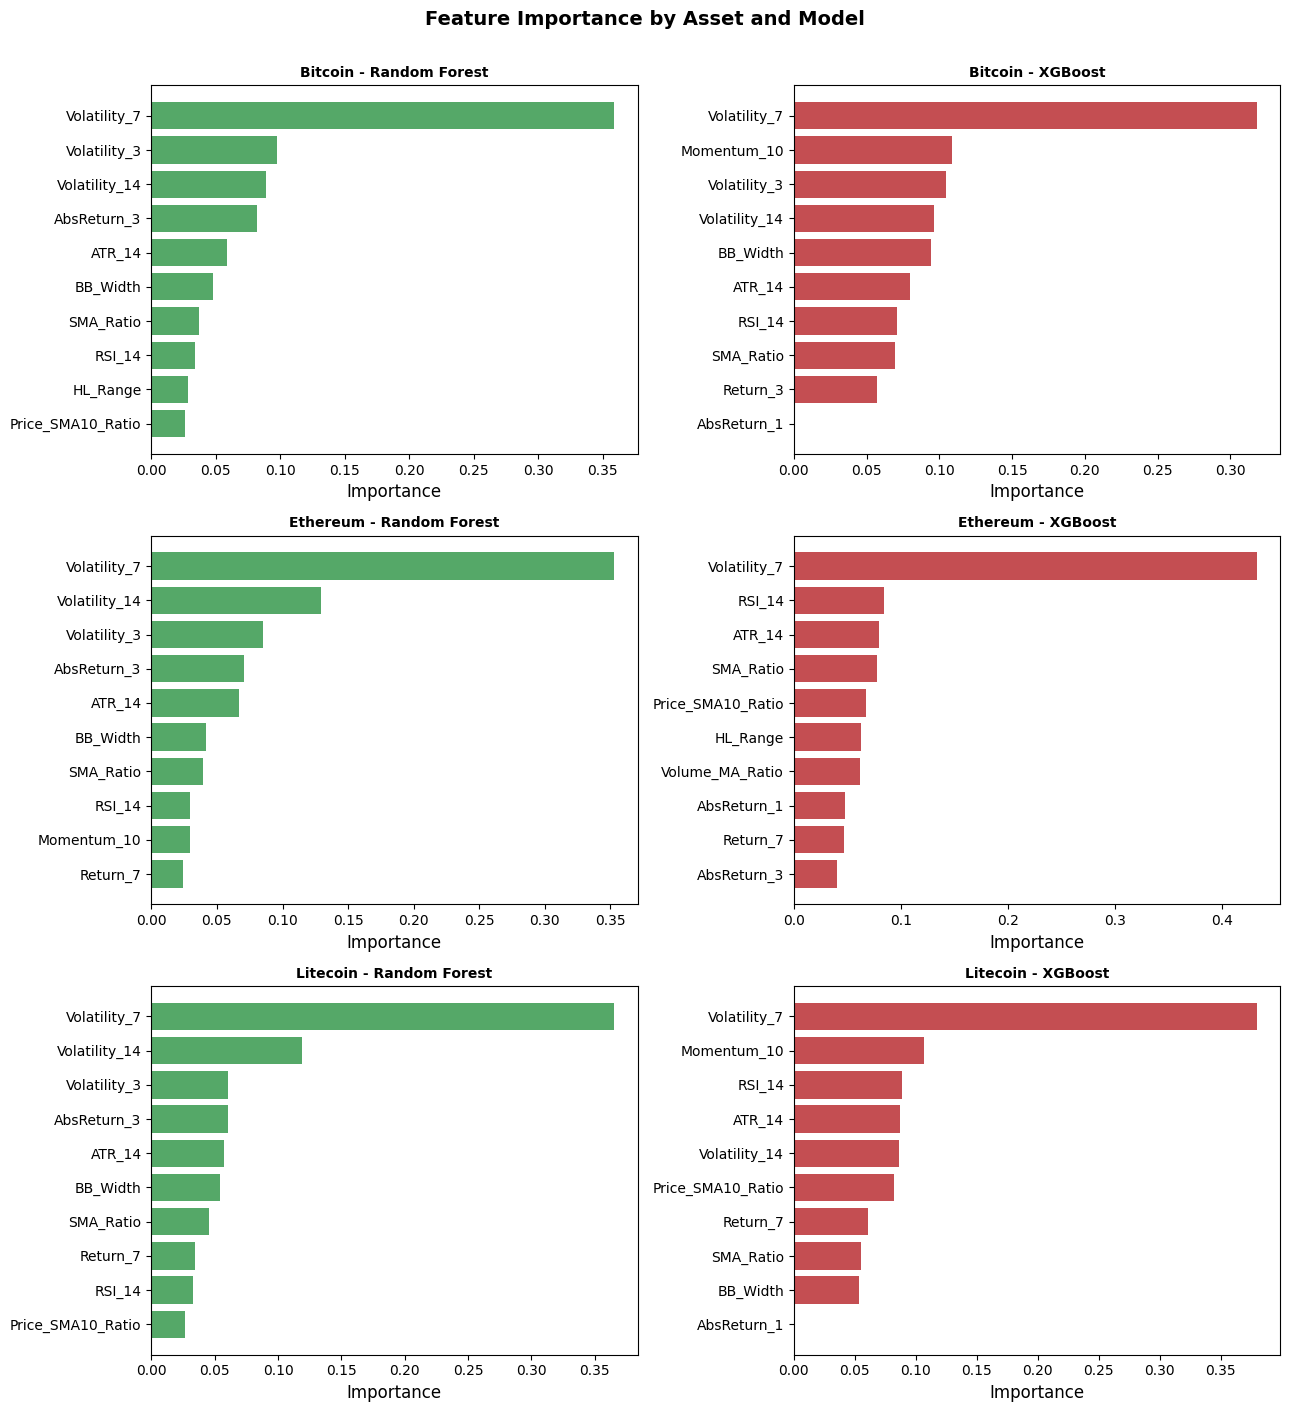

In [ ]:
# ============================================================
# SECTION 26: FEATURE IMPORTANCE (RANDOM FOREST AND XGBOOST)
# ============================================================

fig, axes = plt.subplots(3, 2, figsize=(13, 14))

for row_idx, asset_name in enumerate(assets_order):
    forest_model = fitted_models[asset_name]['Random Forest'][0]
    xgboost_model = fitted_models[asset_name]['XGBoost'][0]

    forest_importance = pd.Series(forest_model.feature_importances_, index=FEATURE_COLUMNS)
    forest_importance = forest_importance.sort_values(ascending=True).tail(10)

    xgboost_importance = pd.Series(xgboost_model.feature_importances_, index=FEATURE_COLUMNS)
    xgboost_importance = xgboost_importance.sort_values(ascending=True).tail(10)

    axes[row_idx, 0].barh(forest_importance.index, forest_importance.values, color='#55A868')
    axes[row_idx, 0].set_title(f'{asset_name} - Random Forest', fontsize=10, fontweight='bold')
    axes[row_idx, 0].set_xlabel('Importance')

    axes[row_idx, 1].barh(xgboost_importance.index, xgboost_importance.values, color='#C44E52')
    axes[row_idx, 1].set_title(f'{asset_name} - XGBoost', fontsize=10, fontweight='bold')
    axes[row_idx, 1].set_xlabel('Importance')

plt.suptitle('Feature Importance by Asset and Model', fontsize=14, fontweight='bold', y=1.005)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 27: TABLE 11 - BEST MODEL PER ASSET
# ============================================================

best_model_summary = (results_df.sort_values('Accuracy', ascending=False)
                       .groupby('Asset').first()
                       .reset_index()[['Asset', 'Model', 'Accuracy', 'F1 Score']])

print("\n" + "=" * 60)
print("TABLE 11: HIGHEST-ACCURACY MODEL PER ASSET")
print("=" * 60)
print(best_model_summary.to_string(index=False))


TABLE 11: HIGHEST-ACCURACY MODEL PER ASSET
   Asset               Model  Accuracy  F1 Score
 Bitcoin Logistic Regression    0.7067    0.7720
Ethereum Logistic Regression    0.6406    0.7485
Litecoin Logistic Regression    0.7013    0.7773


In [ ]:
# ============================================================
# SECTION 28: LSTM PRICE FORECASTING - FEATURE PREPARATION
# ============================================================

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

tf.random.set_seed(42)
np.random.seed(42)

LOOKBACK_WINDOW = 60
TEST_SIZE = 0.2


def build_sequences(scaled_series, window):
    X, y = [], []
    for i in range(window, len(scaled_series)):
        X.append(scaled_series[i - window:i, 0])
        y.append(scaled_series[i, 0])
    return np.array(X), np.array(y)


def prepare_lstm_data(price_df, window=LOOKBACK_WINDOW, test_size=TEST_SIZE):
    close_prices = price_df['Close'].values.reshape(-1, 1)
    split_point = int(len(close_prices) * (1 - test_size))

    train_raw = close_prices[:split_point]
    test_raw = close_prices[split_point:]

    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_raw)

    test_input_raw = close_prices[split_point - window:]
    test_scaled = scaler.transform(test_input_raw)

    X_train, y_train = build_sequences(train_scaled, window)
    X_test, y_test = build_sequences(test_scaled, window)

    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

    return X_train, y_train, X_test, y_test, scaler, train_raw, test_raw


In [ ]:
# ============================================================
# SECTION 29: LSTM MODEL ARCHITECTURE AND TRAINING
# ============================================================

def build_lstm_model(window=LOOKBACK_WINDOW):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(window, 1)),
        Dropout(0.2),
        LSTM(32, return_sequences=False),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


lstm_forecasts = {}
lstm_metrics = []

for asset_name, asset_df in [('Bitcoin', btc), ('Ethereum', eth), ('Litecoin', ltc)]:

    X_train, y_train, X_test, y_test, scaler, train_raw, test_raw = prepare_lstm_data(asset_df)

    lstm_model = build_lstm_model()
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    lstm_model.fit(X_train, y_train, epochs=25, batch_size=64,
                   validation_split=0.1, verbose=0, callbacks=[early_stop])

    predicted_scaled = lstm_model.predict(X_test, verbose=0)
    predicted_prices = scaler.inverse_transform(predicted_scaled).flatten()
    actual_prices = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    naive_predicted = test_raw[LOOKBACK_WINDOW - 1:-1].flatten()
    naive_actual = test_raw[LOOKBACK_WINDOW:].flatten()

    test_start_index = len(asset_df) - len(test_raw)
    sma_series = asset_df['Close'].rolling(30).mean().values
    sma_predicted = sma_series[test_start_index - 1: len(asset_df) - 1]
    sma_actual = asset_df['Close'].values[test_start_index:]
    valid_sma = ~np.isnan(sma_predicted)

    lstm_forecasts[asset_name] = {
        'dates': asset_df['Date'].values[-len(actual_prices):],
        'actual': actual_prices,
        'lstm_predicted': predicted_prices
    }

    lstm_metrics.append({
        'Asset': asset_name,
        'Model': 'LSTM',
        'RMSE': round(np.sqrt(mean_squared_error(actual_prices, predicted_prices)), 2),
        'MAE': round(mean_absolute_error(actual_prices, predicted_prices), 2),
        'R2': round(r2_score(actual_prices, predicted_prices), 4),
        'MAPE (%)': round(np.mean(np.abs((actual_prices - predicted_prices) / actual_prices)) * 100, 2)
    })

    lstm_metrics.append({
        'Asset': asset_name,
        'Model': 'Naive Persistence',
        'RMSE': round(np.sqrt(mean_squared_error(naive_actual, naive_predicted)), 2),
        'MAE': round(mean_absolute_error(naive_actual, naive_predicted), 2),
        'R2': round(r2_score(naive_actual, naive_predicted), 4),
        'MAPE (%)': round(np.mean(np.abs((naive_actual - naive_predicted) / naive_actual)) * 100, 2)
    })

    lstm_metrics.append({
        'Asset': asset_name,
        'Model': '30-Day SMA',
        'RMSE': round(np.sqrt(mean_squared_error(sma_actual[valid_sma], sma_predicted[valid_sma])), 2),
        'MAE': round(mean_absolute_error(sma_actual[valid_sma], sma_predicted[valid_sma]), 2),
        'R2': round(r2_score(sma_actual[valid_sma], sma_predicted[valid_sma]), 4),
        'MAPE (%)': round(np.mean(np.abs((sma_actual[valid_sma] - sma_predicted[valid_sma])
                                          / sma_actual[valid_sma])) * 100, 2)
    })

lstm_results_df = pd.DataFrame(lstm_metrics)

print("\n" + "=" * 60)
print("TABLE 12: LSTM FORECAST PERFORMANCE VS BASELINES")
print("=" * 60)
print(lstm_results_df.to_string(index=False))


TABLE 12: LSTM FORECAST PERFORMANCE VS BASELINES
   Asset             Model    RMSE     MAE     R2  MAPE (%)
 Bitcoin              LSTM 2352.17 1683.33 0.9263      5.19
 Bitcoin Naive Persistence  809.55  515.15 0.9895      1.57
 Bitcoin        30-Day SMA 2688.63 1931.77 0.9037      6.06
Ethereum              LSTM  189.55  136.53 0.9319      5.09
Ethereum Naive Persistence   78.51   49.62 0.9889      1.88
Ethereum        30-Day SMA  239.49  163.73 0.8914      6.17
Litecoin              LSTM    5.50    3.77 0.7621      4.73
Litecoin Naive Persistence    2.97    1.83 0.9269      2.30
Litecoin        30-Day SMA    7.18    5.21 0.5940      6.56


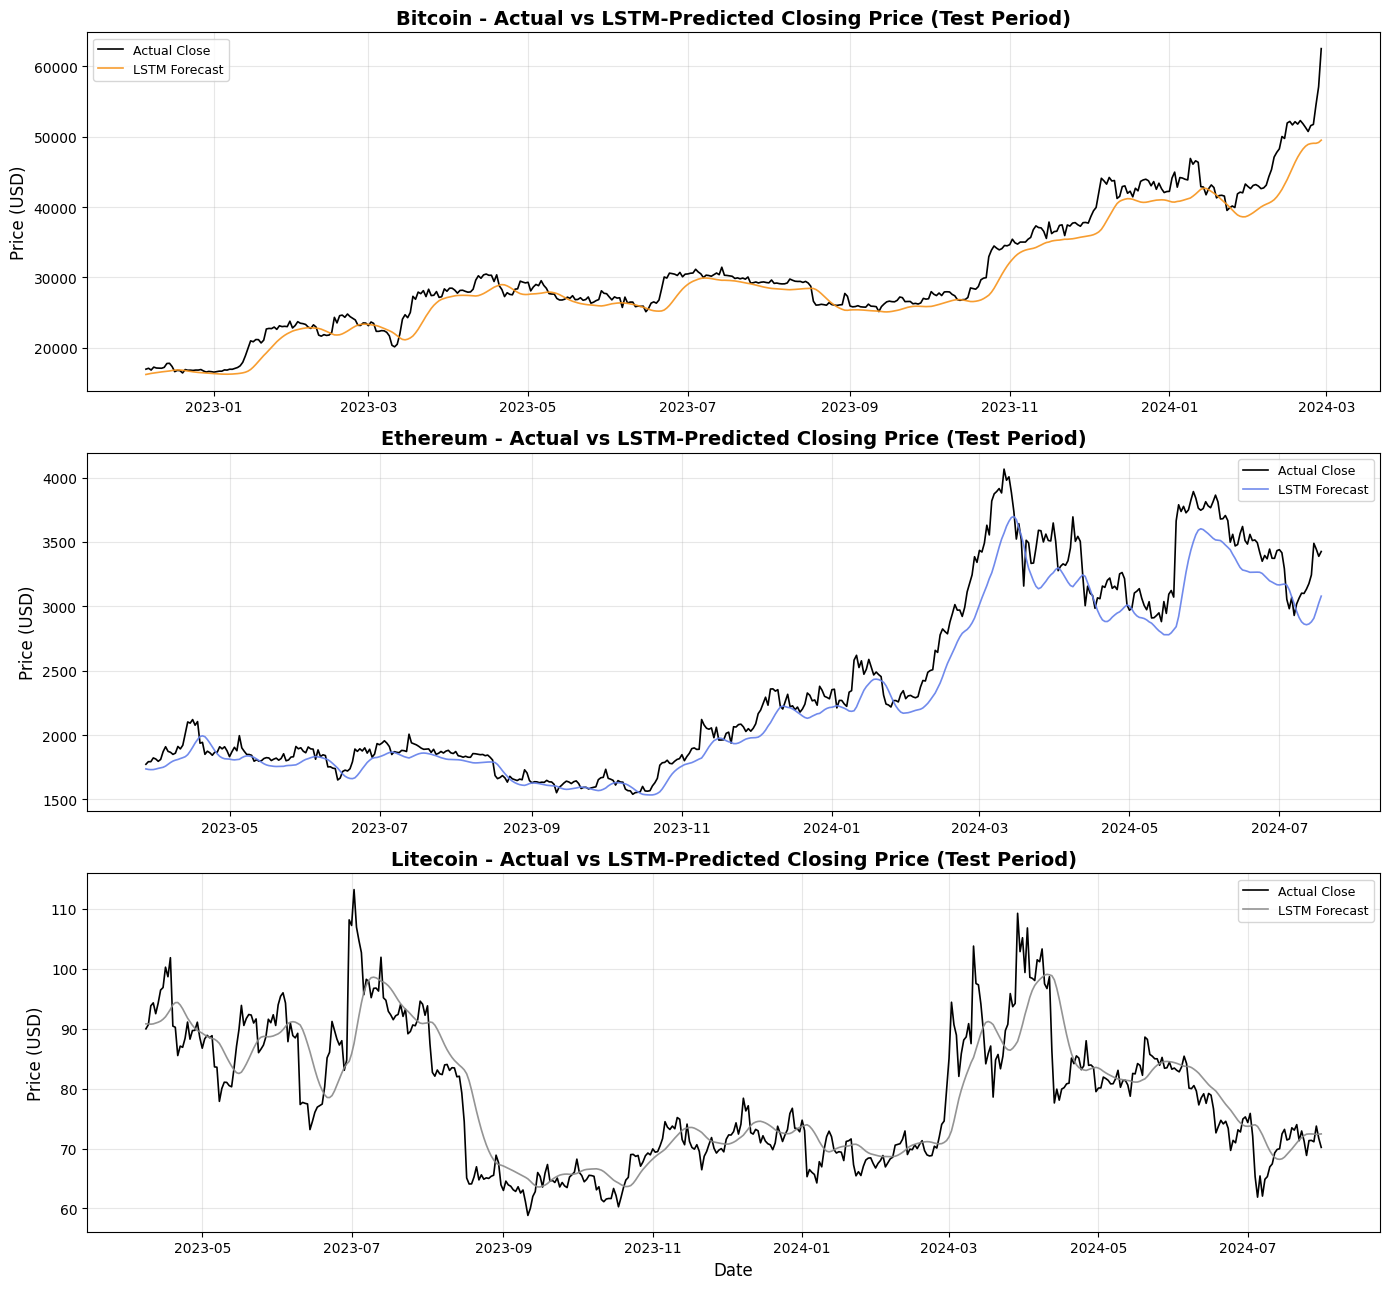

In [ ]:
# ============================================================
# SECTION 30: ACTUAL VS LSTM-PREDICTED PRICE
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 13))

asset_colors = {'Bitcoin': '#F7931A', 'Ethereum': '#627EEA', 'Litecoin': '#888888'}

for ax, asset_name in zip(axes, ['Bitcoin', 'Ethereum', 'Litecoin']):
    forecast_data = lstm_forecasts[asset_name]
    ax.plot(forecast_data['dates'], forecast_data['actual'],
            color='black', linewidth=1.2, label='Actual Close')
    ax.plot(forecast_data['dates'], forecast_data['lstm_predicted'],
            color=asset_colors[asset_name], linewidth=1.2, alpha=0.9, label='LSTM Forecast')
    ax.set_title(f'{asset_name} - Actual vs LSTM-Predicted Closing Price (Test Period)',
                 fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel('Date')
plt.tight_layout()
plt.show()

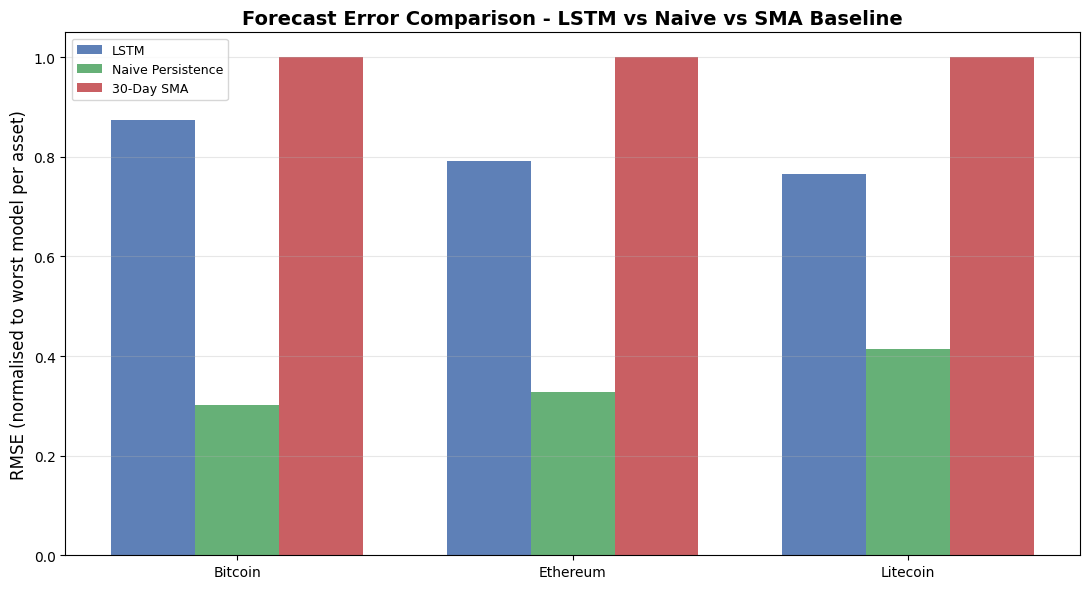

In [ ]:
# ============================================================
# SECTION 31: RMSE COMPARISON ACROSS MODELS
# ============================================================

fig, ax = plt.subplots(figsize=(11, 6))

assets_order = ['Bitcoin', 'Ethereum', 'Litecoin']
models_order = ['LSTM', 'Naive Persistence', '30-Day SMA']
comparison_colors = {'LSTM': '#4C72B0', 'Naive Persistence': '#55A868', '30-Day SMA': '#C44E52'}

bar_width = 0.25
x_positions = np.arange(len(assets_order))

for i, model_name in enumerate(models_order):
    rmse_values = [
        lstm_results_df[(lstm_results_df['Asset'] == a) & (lstm_results_df['Model'] == model_name)]['RMSE'].values[0]
        for a in assets_order
    ]
    normalised_rmse = [
        rmse_values[j] / lstm_results_df[lstm_results_df['Asset'] == assets_order[j]]['RMSE'].max()
        for j in range(len(assets_order))
    ]
    ax.bar(x_positions + (i - 1) * bar_width, normalised_rmse, width=bar_width,
           label=model_name, color=comparison_colors[model_name], alpha=0.9)

ax.set_xticks(x_positions)
ax.set_xticklabels(assets_order)
ax.set_ylabel('RMSE (normalised to worst model per asset)')
ax.set_title('Forecast Error Comparison - LSTM vs Naive vs SMA Baseline', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()